## Paper Figure 5 - Functional clustering of neural responses

This script generates Figure 5 showing functional clustering of neural response types.
It includes UMAP visualization, cluster response profiles, coding score heatmaps,
population average responses, response metrics by cell type, and experience modulation analysis.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import seaborn as sns

sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 1})

# Visual behavior analysis package functions
import visual_behavior.visualization.utils as utils
import visual_behavior.data_access.loading as loading
import visual_behavior.data_access.utilities as utilities

# Clustering modules
from visual_behavior.dimensionality_reduction.clustering import plotting
from visual_behavior.dimensionality_reduction.clustering import processing

# Platform paper figure functions
import visual_behavior.visualization.ophys.platform_paper_figures as ppf
import visual_behavior.visualization.ophys.platform_single_cell_examples as pse

%load_ext autoreload
%autoreload 2
%matplotlib inline

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/xarray/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain 

In [2]:
# Figure saving
save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'figure_5')
os.makedirs(save_dir, exist_ok=True)

## Data Loading

#### Metadata tables

In [3]:
# AllenSDK cache
platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = loading._get_cache()

# Curated metadata tables
metadata_tables_dir = loading.get_metadata_tables_dir()
experiments_table = pd.read_csv(os.path.join(metadata_tables_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
matched_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_matched_ophys_cells_table.csv'), index_col=0)

# Relevant IDs
matched_cells = matched_cells_table.cell_specimen_id.unique()
matched_experiments = matched_cells_table.ophys_experiment_id.unique()

# Cre lines, cell types, and palette for plotting
cre_lines = np.sort(platform_cells_table.cre_line.unique())
cell_types = utils.get_cell_types()
experience_levels = utils.get_experience_levels()
palette = utils.get_experience_level_colors()


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

#### Coding scores

In [4]:

# # Define model version and load GLM results
# glm_version = '24_events_all_L2_optimize_by_session'

# run_params = pd.read_pickle(os.path.join(loading.get_glm_results_dir(), glm_version + '_run_params.pkl'))
# run_params['figure_dir'] = os.path.join(save_dir, 'coding_scores_and_kernels')

# kernels = run_params['kernels']
# all_weights_df = pd.read_hdf( os.path.join(loading.get_glm_results_dir(), 'weights_df.h5'), key='df')

# all_results = pd.read_hdf(os.path.join(loading.get_glm_results_dir(), 'all_results.h5'), key='df')

# all_results_pivoted = pd.read_hdf(os.path.join(loading.get_glm_results_dir(), 'results_pivoted.h5'), key='df')
# all_results_pivoted = processing.set_negative_one_values_to_zero(all_results_pivoted)

# # Split out cell_specimen_id and ophys_experiment_id for results table
# all_results['cell_specimen_id'] = [
#     int(identifier.split('_')[1])
#     for identifier in all_results.identifier.values]

# all_results['ophys_experiment_id'] = [
#     int(identifier.split('_')[0])
#     for identifier in all_results.identifier.values]

# # Get results and weights just for platform paper experiments
# results_pivoted = pd.read_hdf(os.path.join(loading.get_glm_results_dir(), 'platform_results_pivoted.h5'), key='df')
# results_pivoted = processing.set_negative_one_values_to_zero(results_pivoted)

# # Make coding scores positive
# results_pivoted[processing.get_features_for_clustering()] = np.abs(
#     results_pivoted[processing.get_features_for_clustering()])

# weights_df = pd.read_hdf(os.path.join(loading.get_glm_results_dir(), 'platform_results_weights_df.h5'), key='df')



#### Clustering results

In [5]:
glm_results_dir = loading.get_glm_results_dir()
clustering_dir = loading.get_clustering_results_dir()
data_dir = loading.get_clustering_results_dir()

# Load clustering results
feature_matrix = pd.read_hdf(os.path.join(data_dir, 'clustering_feature_matrix.h5'), key='df')
feature_matrix = feature_matrix.rename(columns={'all-images': 'images', 'behavioral': 'behavior'})

n_clusters = 14
cluster_meta = pd.read_hdf(os.path.join(data_dir, f'cluster_metadata_{n_clusters}_clusters.h5'), key='df')

original_feature_matrix = feature_matrix.copy()
original_cluster_meta = cluster_meta.copy()

# Load coding scores - normalized for clustering
results_pivoted = pd.read_hdf(os.path.join(glm_results_dir, 'across_session_normalized_platform_results_pivoted.h5'), key='df')
all_results = pd.read_hdf(os.path.join(glm_results_dir, 'all_results.h5'), key='df')

# Load UMAP results
umap_df = processing.get_umap_results(feature_matrix, cluster_meta, save_dir=clustering_dir, suffix='')

loading umap results from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_clustering_results/umap_results_df.h5


#### Multi-Session Dataframes

In [6]:
# Data type configuration
data_type = 'events'
interpolate = True
output_sampling_rate = 30
inclusion_criteria = 'platform_experiment_table'


conditions = ['cell_specimen_id', 'is_change']
multi_session_df = loading.get_multi_session_df_for_conditions(
    data_type,
    event_type='all',
    conditions=conditions,
    inclusion_criteria=inclusion_criteria,
    interpolate=interpolate,
    output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)

# Separate into change and non-change responses
change_mdf = multi_session_df[multi_session_df.is_change == True]
change_mdf = change_mdf.merge(cluster_meta.reset_index()[['cell_specimen_id', 'cluster_id']], on='cell_specimen_id')

image_mdf = multi_session_df[multi_session_df.is_change == False]
image_mdf = image_mdf.merge(cluster_meta.reset_index()[['cell_specimen_id', 'cluster_id']], on='cell_specimen_id')

# Omission responses
conditions = ['cell_specimen_id', 'omitted']
omission_mdf = loading.get_multi_session_df_for_conditions(
    data_type,
    event_type='all',
    conditions=conditions,
    inclusion_criteria=inclusion_criteria,
    interpolate=interpolate,
    output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)

omission_mdf = omission_mdf[omission_mdf.omitted == True]
omission_mdf = omission_mdf.merge(cluster_meta.reset_index()[['cell_specimen_id', 'cluster_id']], on='cell_specimen_id')

# Remove outliers
threshold_percentile = 99.9  # for removing outliers for pl
image_mdf, image_outliers = processing.remove_outliers(image_mdf, threshold_percentile)
change_mdf, change_outliers = processing.remove_outliers(change_mdf, threshold_percentile)
omission_mdf, omission_outliers = processing.remove_outliers(omission_mdf, threshold_percentile)

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_is_change_platform_experiment_table.feather
there are 1881 experiments in the full multi_session_df
there are 400 experiments in the multi_session_df after limiting to platform experiments
there are 400 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_omitted_platform_experiment_table.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_omitted_platform_experiment_table.feather
there are 1879 experiments in the full multi_session_df
there are 401 experiments in the multi_session_df after limiting to platform experiments
there are 401 experiments after filtering for inclusion criteria -  platform_experiment_table


## Plotting

### Clustered coding scores

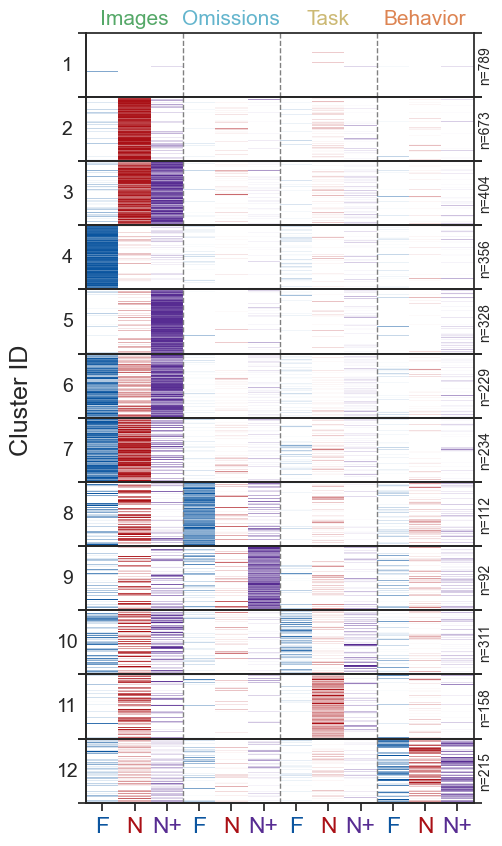

In [7]:
plotting.plot_coding_score_heatmap_matched(cluster_meta, feature_matrix, sort_by='cluster_id',
                                        session_colors=True, experience_index=None, title='',
                                        save_dir=save_dir, folder='cluster_properties', suffix='', ax=None);

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:1570: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (2 levels on the left, 1 on the right)
  cluster_means = feature_matrix.merge(cluster_meta[['cluster_id']], on='cell_specimen_id').groupby('cluster_id').mean()


<Axes: ylabel='Cluster ID'>

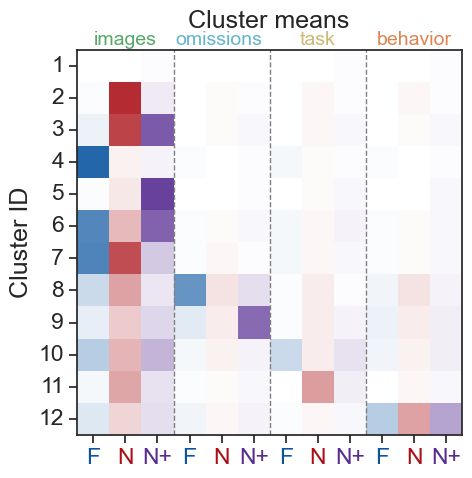

In [8]:
plotting.plot_cluster_means_remapped(
    feature_matrix,
    cluster_meta,
    save_dir=save_dir,
    folder='cluster_properties')


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:1581: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (2 levels on the left, 1 on the right)
  cre_line_means = feature_matrix.merge(cluster_meta[['cre_line']], on='cell_specimen_id').groupby('cre_line').mean()


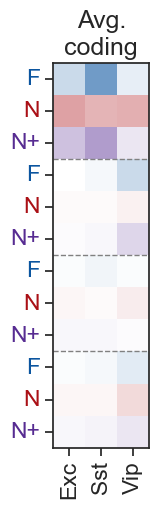

In [9]:
 #plot average coding scores for each cre line (average of matched cells only)
plotting.plot_cre_line_means_remapped(feature_matrix, cluster_meta, save_dir=save_dir, folder='cluster_properties')

### Average image, change, and omission responses per cluster

Generating Panel D: Population average responses...
Familiar
Novel
Novel +
Familiar
Novel
Novel +
Familiar
Novel
Novel +


array([<Axes: title={'center': 'Familiar'}>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
      dtype=object)

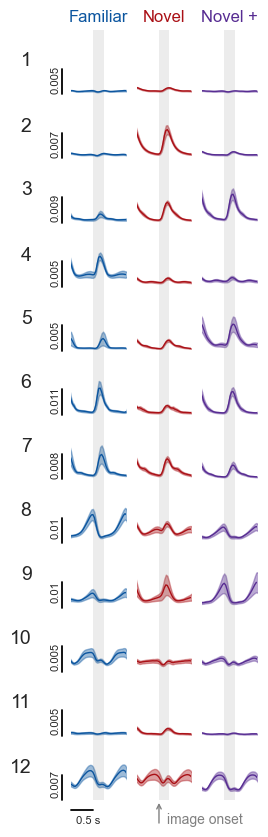

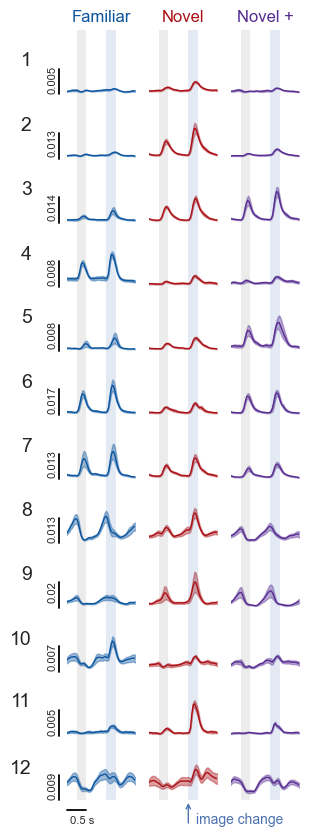

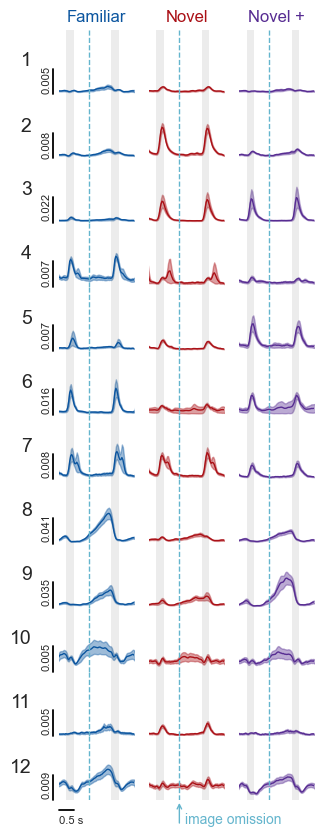

In [10]:
print("Generating Panel D: Population average responses...")

# Image responses
event_type = 'images'
plotting.plot_population_average_response_for_clusters_as_rows_split(
    image_mdf,
    event_type,
    cluster_order=None,
    save_dir=save_dir,
    ax=None)

# Change responses
event_type = 'changes'
plotting.plot_population_average_response_for_clusters_as_rows_split(
    change_mdf,
    event_type,
    with_pre_change=True,
    cluster_order=None,
    save_dir=save_dir,
    ax=None)

# Omission responses
event_type = 'omissions'
plotting.plot_population_average_response_for_clusters_as_rows_split(
    omission_mdf,
    event_type,
    with_pre_change=True,
    cluster_order=None,
    save_dir=save_dir,
    ax=None)


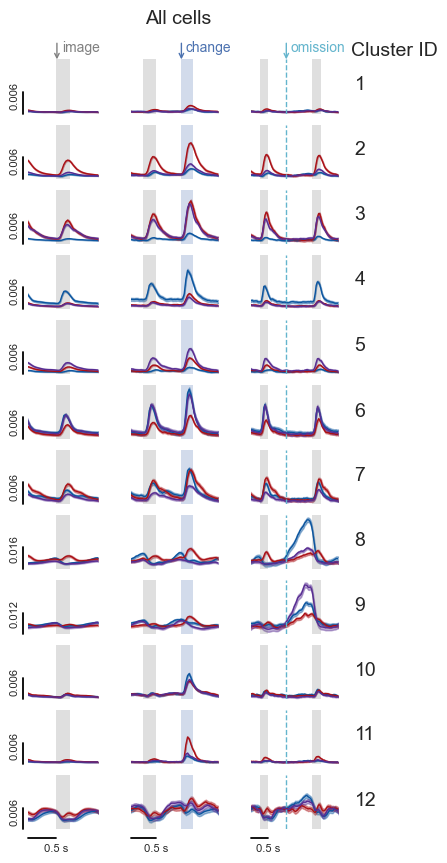

In [11]:
# all cre lines together
suptitle = 'All cells'

plotting.plot_population_average_response_for_clusters_as_rows_all_response_types(image_mdf, change_mdf, omission_mdf, 
                                                                             save_dir=save_dir, suptitle=suptitle, cluster_order=None, ax=None);

23 total removed


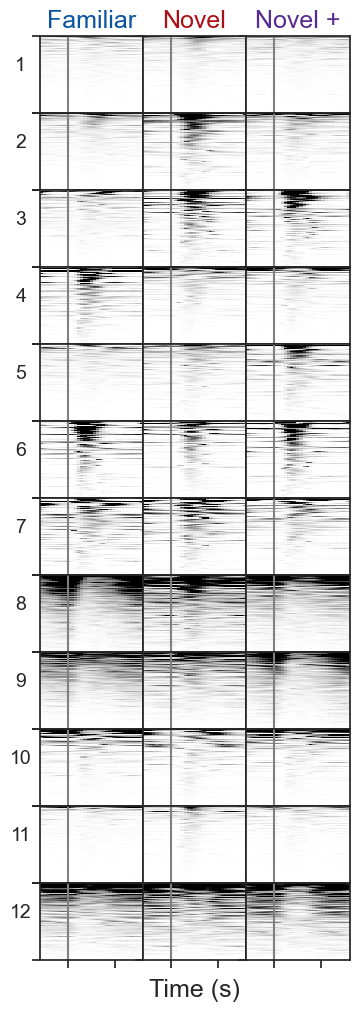

In [12]:
# Response heatmaps for all cells 
plotting.plot_cell_response_heatmaps_for_clusters(image_mdf, data_type='events', event_type='images', 
                                                vmax=0.0005, xlim_seconds=[-0.3, 0.8], ax=None);

### Proportion cells per cluster per cell type 

In [13]:
# save_dir = r'\\allen\programs\braintv\workgroups\nc-ophys\visual_behavior\platform_paper_plots\figure_4\all_cre_clustering_113023'
metrics = processing.generate_merged_table_of_coding_score_and_model_free_metrics(cluster_meta, results_pivoted,
                                                                 data_type='events',
                                                                 session_subset='full_session',
                                                                 inclusion_criteria='platform_experiment_table',
                                                                 save_dir=loading.get_cell_metrics_dir())


# Replace dominant experience level cluster with correct one
cluster_metrics = processing.get_coding_score_metrics_for_clusters(cluster_meta, results_pivoted)

cluster_metrics = cluster_metrics.rename(columns={'dominant_experience_level':'dominant_experience_level_cluster', 
                                                  'dominant_feature': 'dominant_feature_cluster'})


metrics = metrics.rename(columns={'dominant_experience_level_cluster':'dominant_experience_level_old', 
                                                  'dominant_feature_cluster': 'dominant_feature_old'})

response_metrics = metrics.merge(cluster_metrics.reset_index()[['cluster_id', 'dominant_experience_level_cluster', 'dominant_feature_cluster']])


loading coding score and model free metrics table


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2607: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax[i] = sns.barplot(data=cre_data, y='cluster_id', x='percent_cells', order=order, orient='h',
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2607: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax[i] = sns.barplot(data=cre_data, y='cluster_id', x='percent_cells', order=order, orient='h',
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2607: FutureWarning: 

Passing `palette` without assigning `hue` is dep

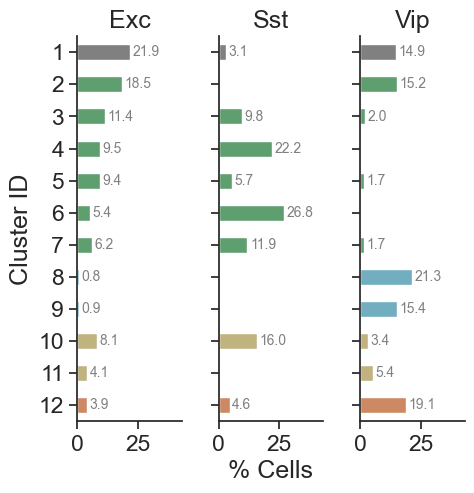

In [14]:
features = response_metrics[['cell_specimen_id', 'dominant_feature_cluster']].drop_duplicates(subset='cell_specimen_id')
tmp = cluster_meta.merge(features, on='cell_specimen_id')

plotting.plot_percent_cells_per_cluster_per_cre_dominant_feature(tmp, cluster_order=None, square=True,
                                                                 col_to_group='cre_line', save_dir=save_dir)

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2607: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax[i] = sns.barplot(data=cre_data, y='cluster_id', x='percent_cells', order=order, orient='h',
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2607: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax[i] = sns.barplot(data=cre_data, y='cluster_id', x='percent_cells', order=order, orient='h',
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2607: FutureWarning: 

Passing `palette` without assigning `hue` is dep

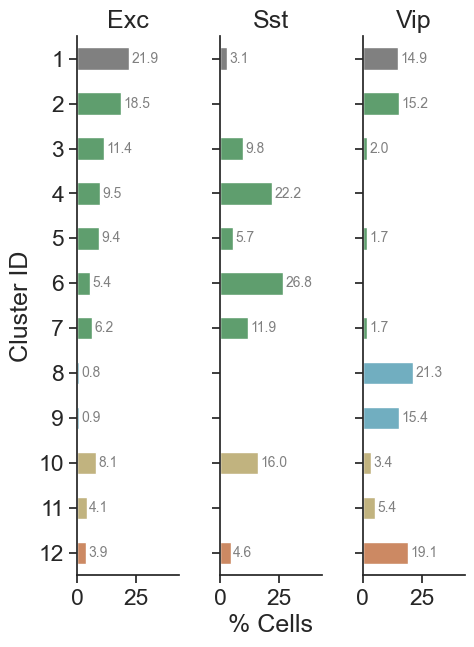

In [15]:
features = response_metrics[['cell_specimen_id', 'dominant_feature_cluster']].drop_duplicates(subset='cell_specimen_id')
tmp = cluster_meta.merge(features, on='cell_specimen_id')

plotting.plot_percent_cells_per_cluster_per_cre_dominant_feature(tmp, cluster_order=None, square=False,
                                                                 col_to_group='cre_line', save_dir=save_dir)

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2687: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax[i] = sns.barplot(data=all_data, y='cluster_id', x='percent_cells', order=order, orient='h',
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2713: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax[i+1] = sns.barplot(data=cre_data, y='cluster_id', x='percent_cells', order=order, orient='h',
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2713: FutureWarning: 

Passing `palette` without assigning `hue` is d

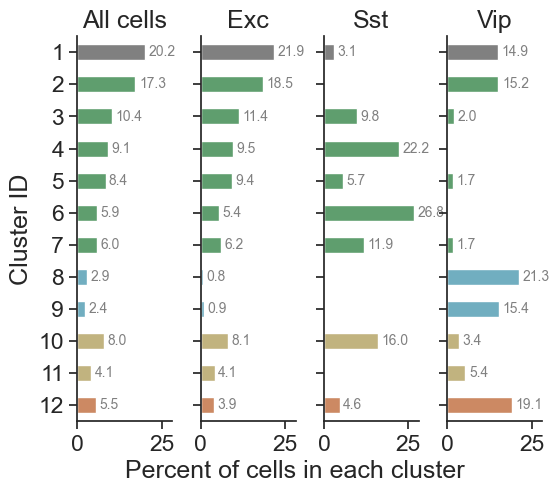

In [16]:
features = response_metrics[['cell_specimen_id', 'dominant_feature_cluster']].drop_duplicates(subset='cell_specimen_id')
tmp = cluster_meta.merge(features, on='cell_specimen_id')

plotting.plot_percent_cells_per_cluster_per_cre_and_all(tmp, col_to_group='cre_line', save_dir=save_dir)

array([<Axes: title={'center': 'Exc'}>, <Axes: title={'center': 'Sst'}>,
       <Axes: title={'center': 'Vip'}>, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: ylabel='Percent of cells in each cluster'>, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: xlabel='Exc'>, <Axes: xlabel='Sst'>,
       <Axes: xlabel='Vip'>], dtype=object)

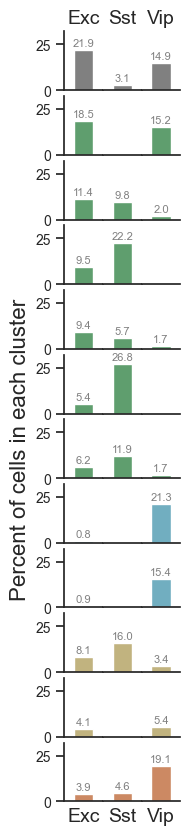

In [17]:
features = response_metrics[['cell_specimen_id', 'dominant_feature_cluster']].drop_duplicates(subset='cell_specimen_id')
tmp = cluster_meta.merge(features, on='cell_specimen_id')


plotting.plot_percent_cells_per_cluster_per_cre_dominant_feature_xaxis(tmp, col_to_group='cre_line', match_height=True,
                                                            cluster_order=None, save_dir=save_dir)

### Proportion of cells per cluster per depth 

In [18]:
location = 'binned_depth'
metric = 'fraction_cells_location'
ylabel = 'Fraction cells in each depth'

n_cells_table = processing.get_cluster_proportion_stats_for_locations(cluster_meta, location=location)
n_cells_table = n_cells_table.reset_index()

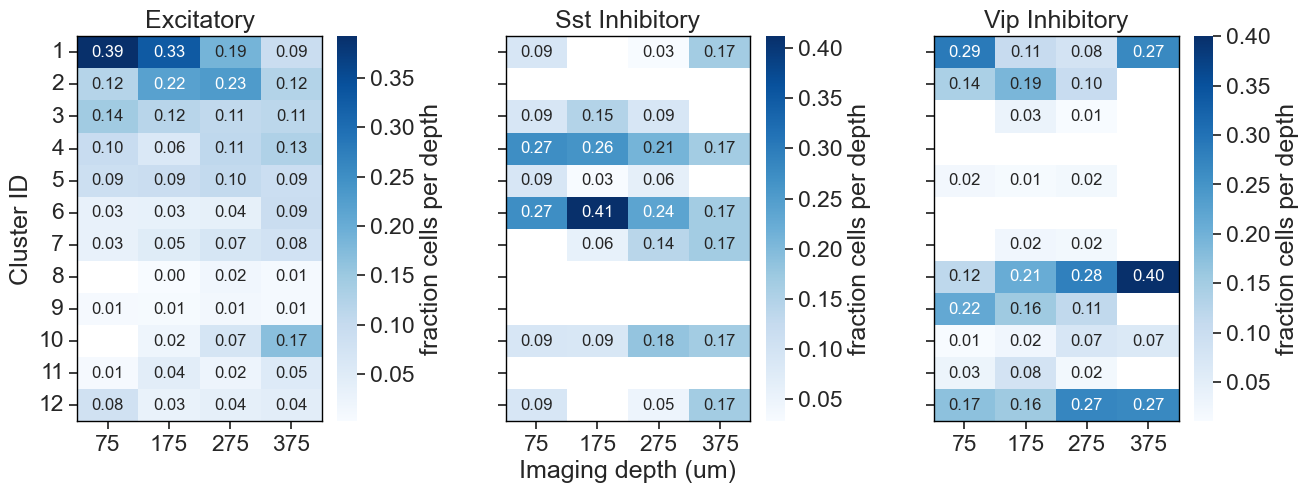

In [19]:
fig, ax = plt.subplots(1,3, figsize=(15,5), sharey=True)
for i, cre_line in enumerate(cre_lines): 
    cell_type = utils.convert_cre_line_to_cell_type(cre_line)
    data = n_cells_table[n_cells_table.cre_line==cre_line]
    pivot = data.pivot_table(index='cluster_id', columns='binned_depth', values='fraction_cells_location')
    # fill in blank values
    for cluster_id in np.arange(1, 13,1): 
        if cluster_id not in pivot.index.values: 
            pivot.loc[cluster_id] = np.nan
    # order
    pivot = pivot.loc[np.arange(1, 13,1)]
    ax[i] = sns.heatmap(pivot, cmap='Blues', ax=ax[i], 
                        annot=True, fmt=".2f", annot_kws={"fontsize": 12},
                        cbar_kws={'label':'fraction cells per depth'})
    ax[i].set_yticklabels(pivot.index.values, rotation=0)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_title(cell_type)
ax[0].set_ylabel('Cluster ID')
ax[1].set_xlabel('Imaging depth (um)')
for i in range(3):
    for _, spine in ax[i].spines.items():
        spine.set_visible(True)
        spine.set_color('black')  # Set the color of the box
        spine.set_linewidth(1) 
fig.subplots_adjust(wspace=0.4)

In [20]:
def get_pivoted_data_for_cell_counts(n_cells_table, cre_line, cluster_ids=np.arange(1,13,1),
                                     column='binned_depth', value='fraction_cells_location'):
    data = n_cells_table[n_cells_table.cre_line==cre_line]
    pivot = data.pivot_table(index='cluster_id', columns=column, values=value)
    # fill in blank values
    for cluster_id in cluster_ids: 
        if cluster_id not in pivot.index.values: 
            pivot.loc[cluster_id] = np.nan
    # order numerically
    pivot = pivot.loc[cluster_ids]
    return pivot

get_pivoted_data_for_cell_counts(n_cells_table, cre_line, value='fraction_cells_location')

binned_depth,75,175,275,375
cluster_id,,,,
1,0.290323,0.107317,0.083333,0.266667
2,0.139785,0.190244,0.104167,NaN
3,NaN,0.034146,0.010417,NaN
4,NaN,NaN,NaN,NaN
5,0.021505,0.014634,0.020833,NaN
6,NaN,NaN,NaN,NaN
7,NaN,0.024390,0.020833,NaN
8,0.118280,0.209756,0.281250,0.400000
9,0.215054,0.156098,0.114583,NaN


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:5847: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  ax[i] = sns.barplot(data=cre_data, y='cluster_id', order=xorder, x=metric, orient='h',
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:5847: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  ax[i] = sns.barplot(data=cre_data, y='cluster_id', order=xorder, x=metric, orient='h',
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:5847: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  ax[i] = sns.barplot(data=cre_data, y='cluster_id', order=xorder, x=metric, orient='h',


array([<Axes: title={'center': 'Exc'}, ylabel='Cluster ID'>,
       <Axes: title={'center': 'Sst'}, xlabel='Fraction cells in each depth'>,
       <Axes: title={'center': 'Vip'}>], dtype=object)

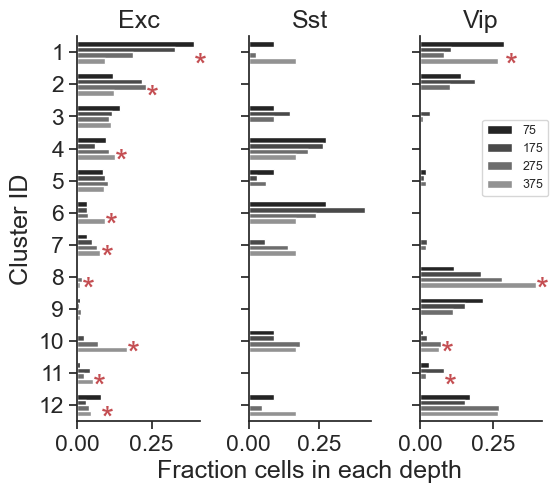

In [21]:
location = 'binned_depth'
metric = 'fraction_cells_location'
ylabel = 'Fraction cells in each depth'

plotting.plot_cluster_depth_distribution_by_cre_lines(cluster_meta, location, metric, horiz=False,
                                                      ylabel=ylabel, save_dir=save_dir, folder='cluster_properties')

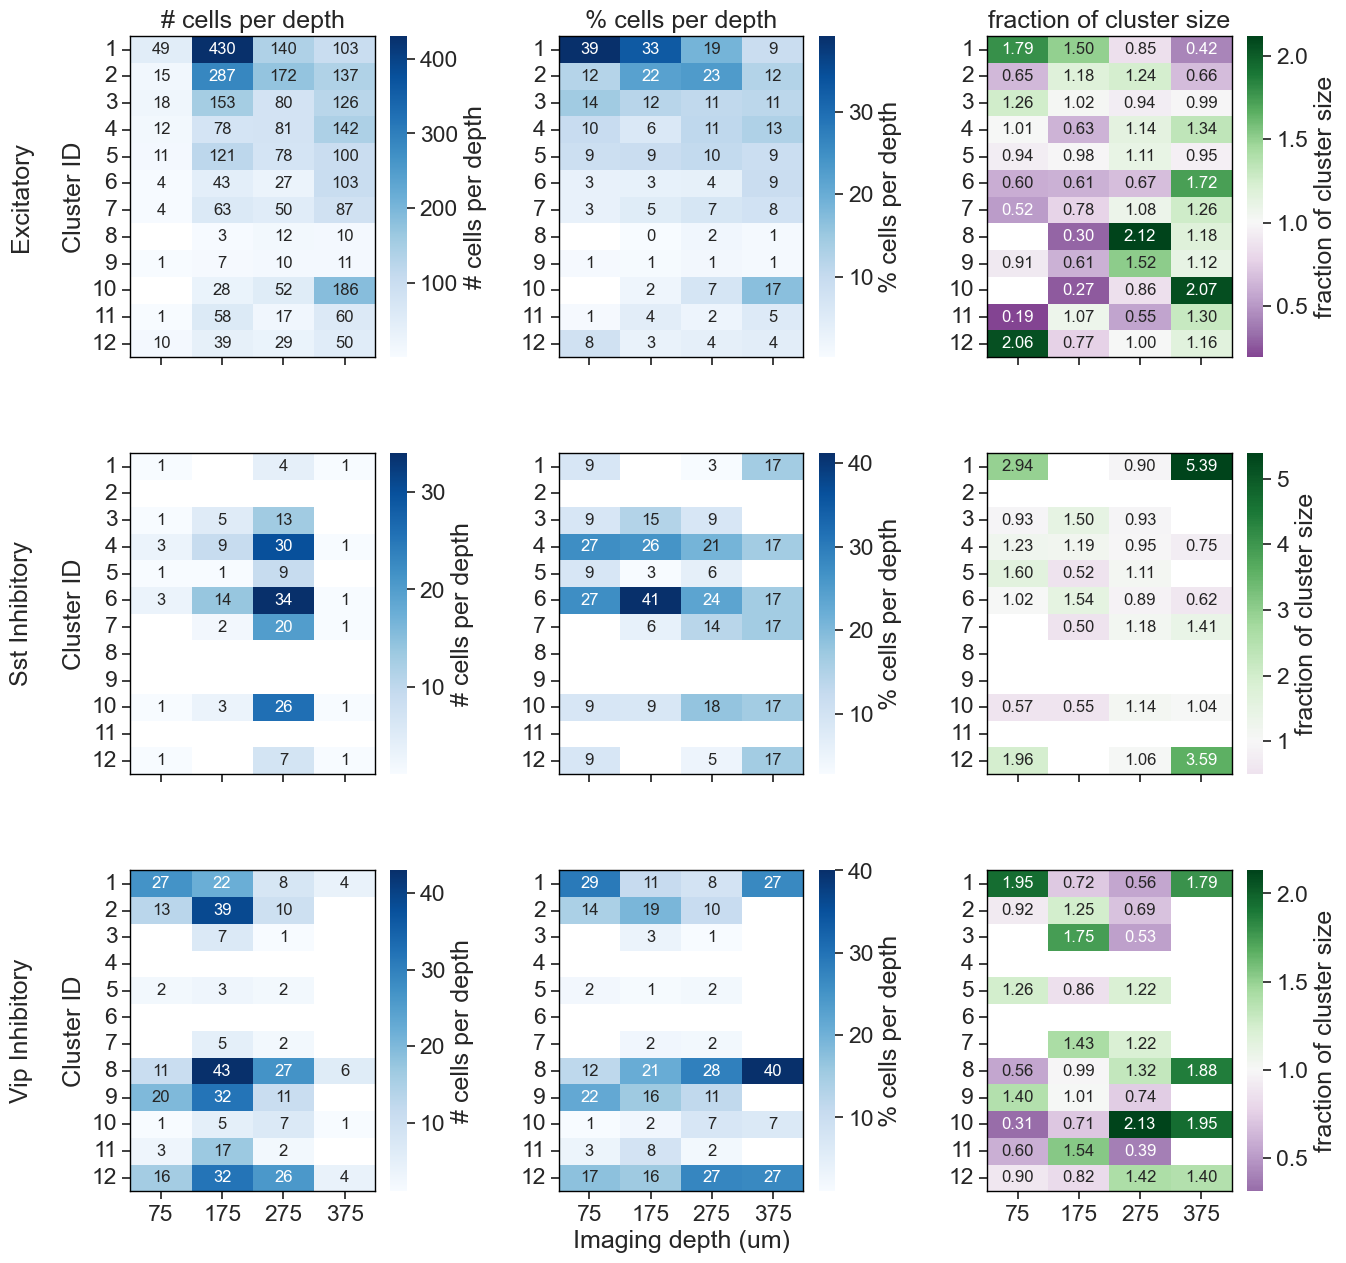

In [22]:

cluster_ids = np.sort(n_cells_table.cluster_id.unique())

fig, ax = plt.subplots(3, 3, figsize=(15, 15), sharey=False, sharex=True)
ax = ax.ravel()
i=0
for c, cre_line in enumerate(cre_lines): 
    cell_type = utils.convert_cre_line_to_cell_type(cre_line)
    pivot = get_pivoted_data_for_cell_counts(n_cells_table, cre_line, value='n_cells_location', cluster_ids=cluster_ids)
    ax[i] = sns.heatmap(pivot, cmap='Blues', ax=ax[i], annot=True, fmt=".0f", annot_kws={"fontsize": 12},
                        cbar_kws={'label':'# cells per depth'})
    ax[i].set_ylabel(cell_type+'\n\nCluster ID')
    if c==0: 
        ax[i].set_title('# cells per depth')
    i+=1
    pivot = get_pivoted_data_for_cell_counts(n_cells_table, cre_line, value='percent_cells_location', cluster_ids=cluster_ids)
    ax[i] = sns.heatmap(pivot, cmap='Blues', ax=ax[i], annot=True, fmt=".0f", annot_kws={"fontsize": 12},
                        cbar_kws={'label':'% cells per depth'})
    ax[i].set_ylabel('')
    if c==0: 
        ax[i].set_title('% cells per depth')
    i+=1
    pivot = get_pivoted_data_for_cell_counts(n_cells_table, cre_line, value='fraction_of_cluster_size', cluster_ids=cluster_ids)
    ax[i] = sns.heatmap(pivot, cmap='PRGn', center=1, ax=ax[i], annot=True, fmt=".2f", annot_kws={"fontsize": 12},
                        cbar_kws={'label':'fraction of cluster size'})
    ax[i].set_ylabel('')
    if c==0: 
        ax[i].set_title('fraction of cluster size')
    i+=1

for i in range(9):
    ax[i].set_xlabel('') 
    ax[i].set_yticklabels(cluster_ids, rotation=0)
    for _, spine in ax[i].spines.items():
        spine.set_visible(True)
        spine.set_color('black')  # Set the color of the box
        spine.set_linewidth(1)   
ax[7].set_xlabel('Imaging depth (um)')
fig.subplots_adjust(hspace=0.3, wspace=0.4)

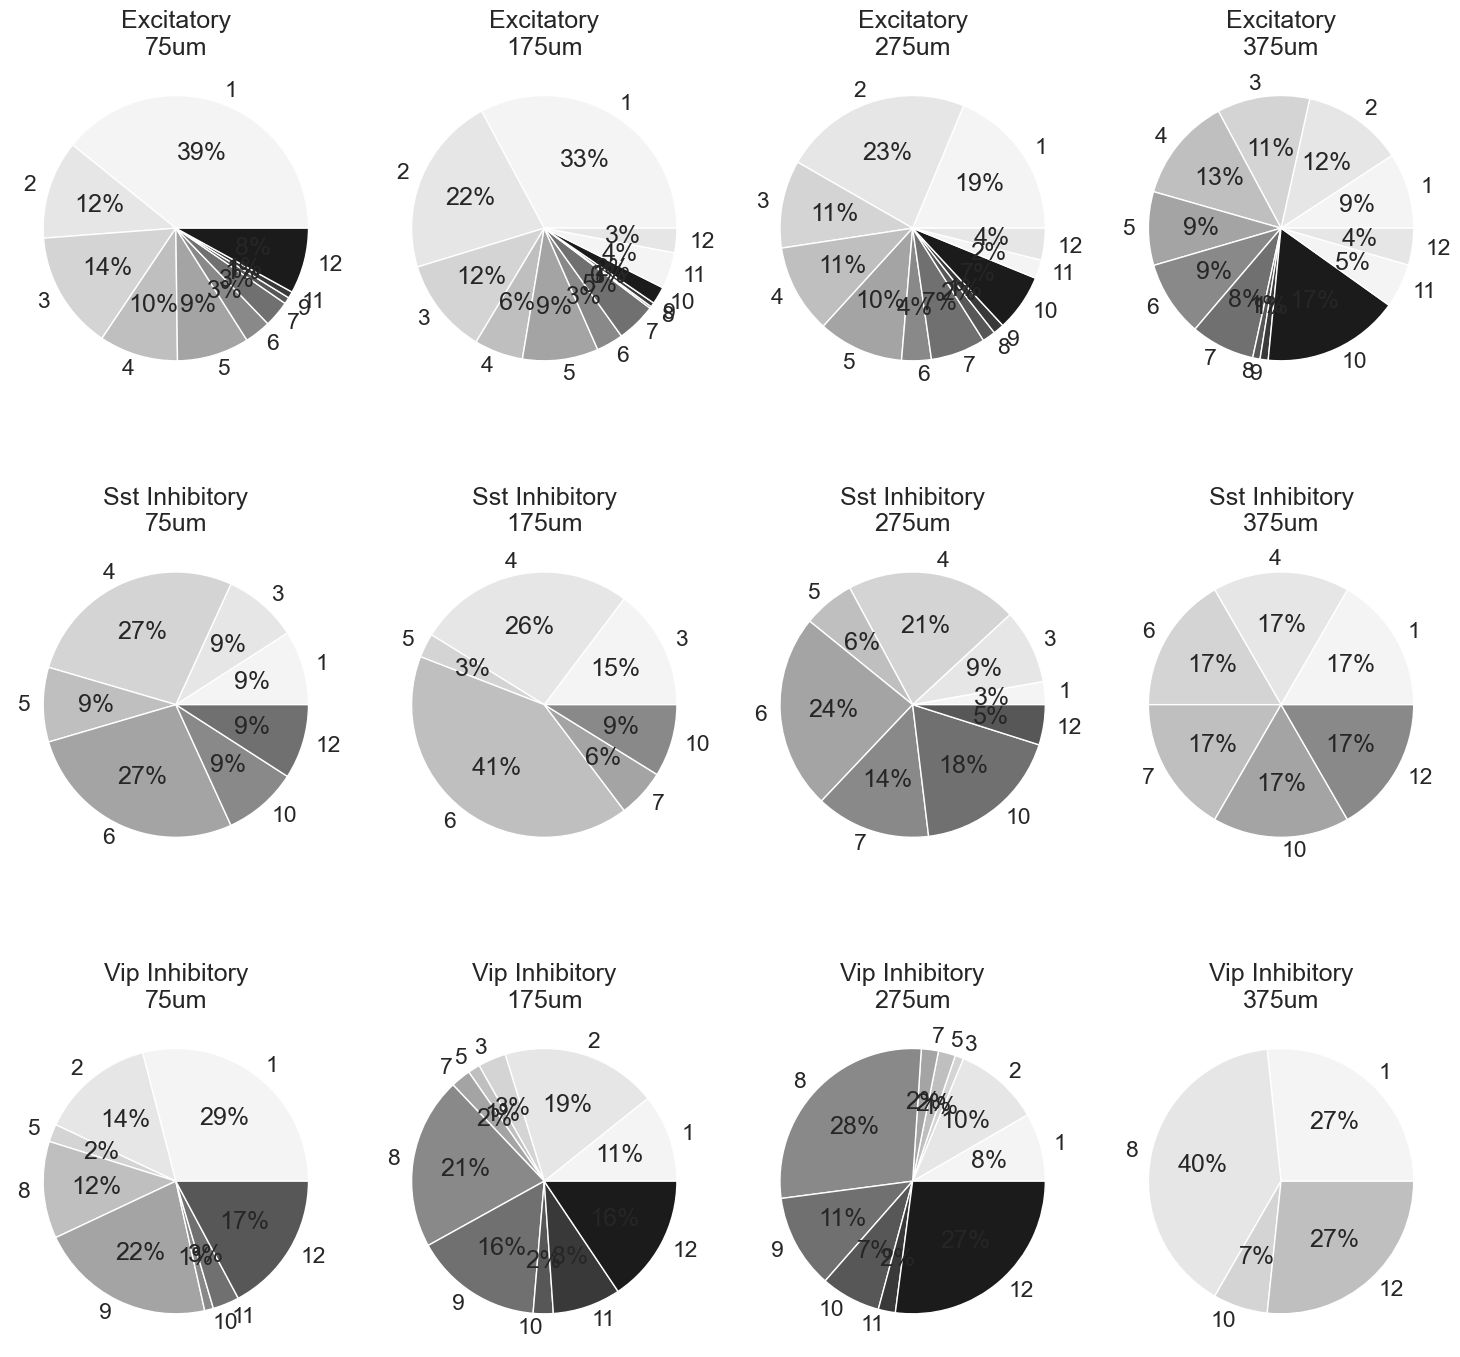

In [23]:
plotting.plot_proportion_cells_per_depth_pie_chart(cluster_meta, save_dir=None, folder=None)

### Give clusters meaningful names and plot UMAP with names instead of cluster IDs

In [24]:
import umap

In [25]:
umap_df = processing.get_umap_results(feature_matrix, cluster_meta, save_dir=clustering_dir, suffix='')

loading umap results from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_clustering_results/umap_results_df.h5


In [26]:
# limit cluster meta to cells that are not in cluster 1 (which is an outlier in the plot)
main_cluster_meta = cluster_meta[cluster_meta.cluster_id!=1]
# limit umap_df to non-cluster 1
umap_df = umap_df.loc[main_cluster_meta.index.values]
# identify other non-outlier points and limit both tables to those
csids = umap_df[umap_df.x<16].index.values
main_cluster_meta = main_cluster_meta.loc[csids]
umap_df = umap_df.loc[csids]
print(len(umap_df), len(main_cluster_meta))
umap_df.head()

2941 2941


,x,y,cluster_id
cell_specimen_id,,,
1086489847,4.780380,7.625232,12
1086489860,9.371953,2.737884,2
1086489891,4.785028,7.619345,12
1086489976,6.144250,11.332527,4
1086490002,9.028252,10.901272,4


In [27]:
exp_colors = utils.get_experience_level_colors()
gray = (0.8, 0.8, 0.8)
cluster_color_dict = {1: gray, # non coding - gray
                      2: exp_colors[1], # novel image coding - red
                      3: exp_colors[2], # persistent novel image coding - purple 
                      4: exp_colors[0], # familiar image coding - blue
                      5: gray, # weird coding - gray
                      6: exp_colors[2], # novelty suppression - purple
                      7: gray, # everything coding gray
                      8: exp_colors[0], # omission coding during familiar - blue
                      9: exp_colors[2], # omission coding during novel+ - purple
                      10: exp_colors[0], # task coding during familiar - blue
                      11: gray, # task coding during novel - gray
                      12: gray, # behavior coding - gray
                      }

colors = [cluster_color_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]

feature_colors = plotting.get_feature_colors_with_gray()
edge_color_dict = {1: gray, # non coding - gray
                      2: feature_colors[1], # image coding
                      3: feature_colors[1], # image coding
                      4: feature_colors[1], # image coding
                      5: gray, # image coding
                      6: feature_colors[1], # image coding 
                      7: gray, # image coding
                      8: feature_colors[2], # omission coding
                      9: feature_colors[2], # omission coding
                      10: feature_colors[3], # task coding
                      11: gray, # task coding
                      12: feature_colors[4], # behavior coding
                      }

edge_colors = [edge_color_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]

labels_dict = {1: '', # non coding - gray
                2: 'novelty enhanced', # novel image coding - red
                3: 'novel image coding', # persistent novel image coding - purple 
                4: 'familiar image coding', # familiar image coding - blue
                5: '', # weird coding - gray
                6: 'novelty suppressed', # novelty suppression - purple
                7: '', # everything coding gray
                8: 'omission coding', # omission coding during familiar - blue
                9: 'omission coding', # omission coding during novel+ - purple
                10: 'task coding', # task coding during familiar - blue
                11: '', # task coding during novel - gray
                12: 'behavior coding', # behavior coding - gray
                }
labels = [labels_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]


markers_dict = {'Exc': 'o', # '^'
                'Sst': 's', # 'o'
                'Vip': 'd'}

markers = [markers_dict[main_cluster_meta.loc[cell_specimen_id]['cell_type'][:3]] for cell_specimen_id in main_cluster_meta.index.values]

/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6860/1921626422.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize='xx-small', title='', title_fontsize='xx-small', bbox_to_anchor=(1, 1))


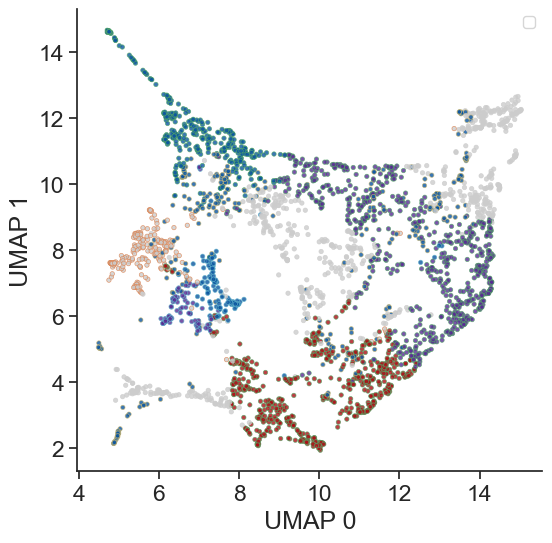

In [28]:
figsize = (6, 6)

fig, ax = plt.subplots(figsize=figsize)

umap_df['labels'] = labels
ax = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax, #label=labels,
                     color=colors, edgecolor=edge_colors, markers=markers, linewidth=0.5, alpha=0.8)

ax.set_xlabel('UMAP 0')
ax.set_ylabel('UMAP 1')
ax.legend(fontsize='xx-small', title='', title_fontsize='xx-small', bbox_to_anchor=(1, 1))


/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6860/2304824910.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize='xx-small', title='', title_fontsize='xx-small', bbox_to_anchor=(1, 1))


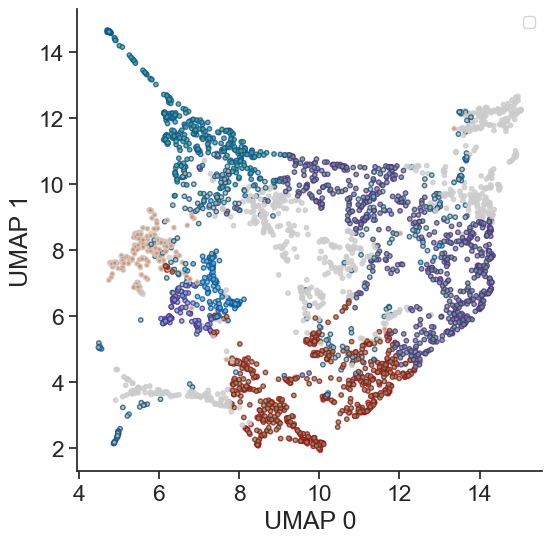

In [29]:
figsize = (6, 6)

fig, ax = plt.subplots(figsize=figsize)

umap_df['labels'] = labels
ax = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax, #label=labels,
                     color=edge_colors, edgecolor=colors, markers=markers, linewidth=1, alpha=0.8)

ax.set_xlabel('UMAP 0')
ax.set_ylabel('UMAP 1')
ax.legend(fontsize='xx-small', title='', title_fontsize='xx-small', bbox_to_anchor=(1, 1))
# ax.set_title(utils.get_cell_type_for_cre_line(cre_line, cluster_meta))

# plt.subplots_adjust(wspace=0.3)
# if save_dir:
#     utils.save_figure(fig, figsize, save_dir, folder, 'UMAP_' + label_col)


Text(0, 0.5, 'UMAP 1')

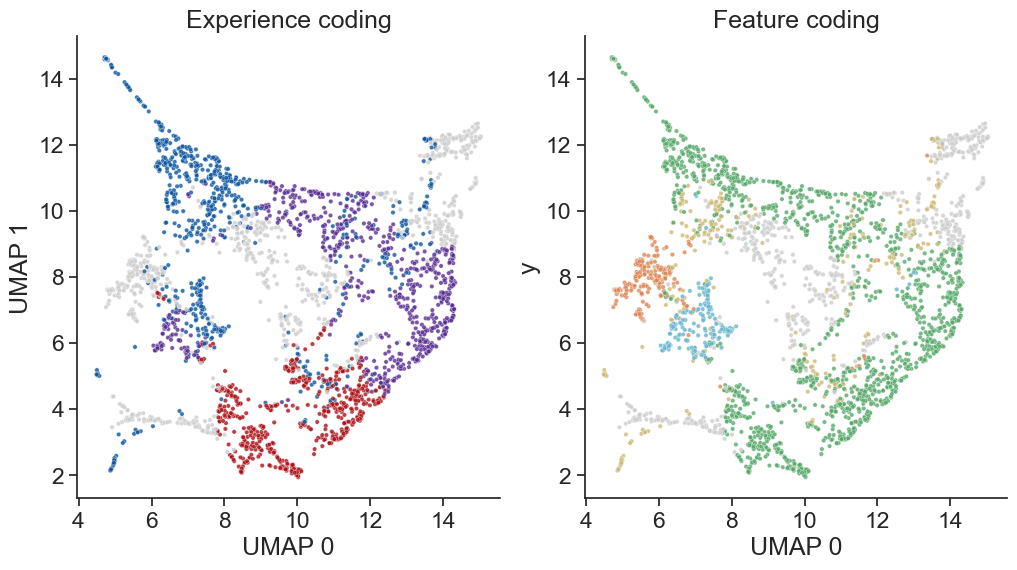

In [30]:
figsize = (12, 6)

fig, ax = plt.subplots(1, 2, figsize=figsize)

umap_df['labels'] = labels
ax[0] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[0], #label=labels,
                     color=colors, markers=markers, alpha=0.8)
ax[0].set_title('Experience coding')
ax[1] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[1], #label=labels,
                     color=edge_colors, markers=markers, alpha=0.8)
ax[1].set_title('Feature coding')
ax[0].set_xlabel('UMAP 0')
ax[1].set_xlabel('UMAP 0')
ax[0].set_ylabel('UMAP 1')

In [31]:
# umap_df['cell_type'] = [cell_type[:3] for cell_type in main_cluster_meta.cell_type.values]
# markers_dict = {'Exc': 'o', # '^'
#                 'Sst': 's', # 'o'
#                 'Vip': 'd'}

# figsize = (12, 6)

# fig, ax = plt.subplots(1, 2, figsize=figsize)

# umap_df['labels'] = labels
# ax[0] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[0], style='cell_type',
#                      color=colors, markers=markers_dict, alpha=0.8, linewidth=0)
# ax[0].set_title('Experience coding')
# ax[1] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[1], style='cell_type',
#                      color=edge_colors, markers=markers_dict, alpha=0.8, linewidth=0)
# ax[1].set_title('Feature coding')
# ax[0].set_xlabel('UMAP 0')
# ax[1].set_xlabel('UMAP 0')
# ax[0].set_ylabel('UMAP 1')

#### Try with new colors for specific cluster types

In [32]:

labels_dict = {1: 'other', # non coding - gray
                2: 'novelty enhanced', # novel image coding - red #AB0F15
                3: 'novel image coding', # persistent novel image coding -  reddish purple #A2258F
                4: 'familiar image coding', # familiar image coding - blue #0B549D
                5: 'other', # weird coding - gray
                6: 'novelty suppressed', # novelty suppression - light red #E38686
                7: 'other', # everything coding gray
                8: 'familiar omission coding', # omission coding during familiar - light blue #71A9DE
                9: 'novel+ omission coding', # omission coding during novel+ - light purple #9A79C9
                10: 'task coding', # task coding during familiar - yellow #DBD689
                11: 'other', # task coding during novel - gray
                12: 'behavior coding', # behavior coding - orange #FAB171
                }
labels = [labels_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]

cluster_id_labels = ['cluster '+str(main_cluster_meta.loc[cell_specimen_id]['cluster_id']) for cell_specimen_id in main_cluster_meta.index.values]

labels_dict = {1: 'other', # non coding - gray
                2: 'novelty enhanced', # novel image coding - red #AB0F15
                3: 'novel image coding', # persistent novel image coding -  reddish purple #A2258F
                4: 'familiar image coding', # familiar image coding - blue #0B549D
                5: 'other', # weird coding - gray
                6: 'novelty suppressed', # novelty suppression - light red #E38686
                7: 'other', # everything coding gray
                8: 'familiar omission coding', # omission coding during familiar - light blue #71A9DE
                9: 'novel+ omission coding', # omission coding during novel+ - light purple #9A79C9
                10: 'task coding', # task coding during familiar - yellow #DBD689
                11: 'other', # task coding during novel - gray
                12: 'behavior coding', # behavior coding - orange #FAB171
                }
labels = [labels_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]


# gray = #BFBFBF
clutster_colors_dict = {1: '#BFBFBF', # non coding - gray #BFBFBF
                2: '#AB0F15', # novel image coding - red #AB0F15
                3: '#A2258F', # persistent novel image coding -  reddish purple #A2258F
                4: '#0B549D', # familiar image coding - blue #0B549D
                5: '#BFBFBF', # weird coding - gray
                6: '#E38686', # novelty suppression - light red #E38686
                7: '#BFBFBF', # everything coding gray
                8: '#71A9DE', # omission coding during familiar - light blue #71A9DE
                9: '#9A79C9', # omission coding during novel+ - light purple #9A79C9
                10: '#DBD689', # task coding during familiar - yellow #DBD689
                11: '#BFBFBF', # task coding during novel - gray
                12: '#FAB171', # behavior coding - orange #FAB171
                }
new_colors = [clutster_colors_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]


markers_dict = {'Exc': 'o', # '^'
                'Sst': 's', # 'o'
                'Vip': 'd'}

markers = [markers_dict[main_cluster_meta.loc[cell_specimen_id]['cell_type'][:3]] for cell_specimen_id in main_cluster_meta.index.values]

In [33]:
umap_df['cluster_id'] = [main_cluster_meta.loc[cell_specimen_id]['cluster_id'] for cell_specimen_id in main_cluster_meta.index.values]
umap_df['cluster_label'] = [labels_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]
umap_df['cluster_id'] = ['cluster '+str(main_cluster_meta.loc[cell_specimen_id]['cluster_id']) for cell_specimen_id in main_cluster_meta.index.values]
umap_df['cell_type'] = [cell_type for cell_type in main_cluster_meta.cell_type.values]
umap_df.head()

,x,y,cluster_id,labels,cluster_label,cell_type
cell_specimen_id,,,,,,
1086489847,4.780380,7.625232,cluster 12,behavior coding,behavior coding,Vip Inhibitory
1086489860,9.371953,2.737884,cluster 2,novelty enhanced,novelty enhanced,Vip Inhibitory
1086489891,4.785028,7.619345,cluster 12,behavior coding,behavior coding,Vip Inhibitory
1086489976,6.144250,11.332527,cluster 4,familiar image coding,familiar image coding,Sst Inhibitory
1086490002,9.028252,10.901272,cluster 4,familiar image coding,familiar image coding,Sst Inhibitory


In [34]:
red = sns.color_palette('Reds_r', 6).as_hex()[0]
blue = sns.color_palette('Blues_r', 6).as_hex()[0]
purple = sns.color_palette('Purples_r', 6).as_hex()[0]
print(red, blue, purple)

red = sns.color_palette('Reds_r', 6).as_hex()[2]
blue = sns.color_palette('Blues_r', 6).as_hex()[2]
purple = sns.color_palette('Purples_r', 6).as_hex()[2]
print(red, blue, purple)

#aa1016 #0b559f #572c92
#f44f39 #539ecd #8d89c0


In [35]:
hue_order = umap_df.cluster_label.unique()
hue_order = [ 'novelty enhanced', 'novelty suppressed',
             'novel image coding', 'familiar image coding', 
             'novel+ omission coding','familiar omission coding', 
             'task coding', 'behavior coding', 'other']

palette = ['#aa1016', # novelty enhanced - red #AB0F15, #aa1016 
           '#55a868', # novelty suppressed - light red #E38686, #fc8161, pink #E68C8F, green #55a868
            '#572c92', # novel image coding -  purple #A2258F, #572c92
            '#0b559f', # familiar image coding - blue #0B549D, #0b559f 
            '#8d89c0', # omission coding during novel+ - light purple #9A79C9, #afaed4
            '#539ecd', # omission coding during familiar - light blue #71A9DE, #89bedc 
            '#ccb974', # task coding during familiar - yellow #DBD689
            '#dd8452', # behavior coding - orange #FAB171
            '#BFBFBF',] # non coding - gray #BFBFBF


Text(0.5, 1.0, 'Main clusters')

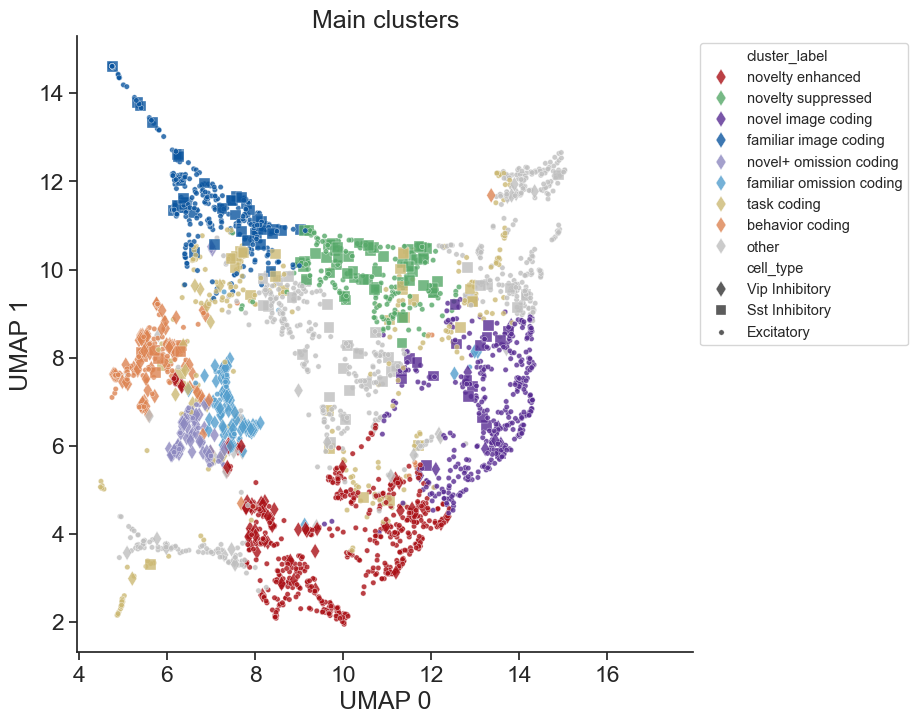

In [36]:
figsize = (8,8)
fig, ax = plt.subplots(figsize=figsize)

markers_dict = {'Excitatory': '.', # '^'
                'Sst Inhibitory': 's', # 'o', 's'
                'Vip Inhibitory': 'd'}

ax = sns.scatterplot(data=umap_df, x='x', y='y', s=60, ax=ax, #label=labels,
                     hue='cluster_label', hue_order=hue_order, style='cell_type', 
                     palette=palette, markers=markers_dict, linewidth=0.3, alpha=0.8, edgecolor='w')
ax.set_xlabel('UMAP 0')
ax.set_ylabel('UMAP 1')
ax.axis('square')
ax.legend(fontsize='xx-small', title_fontsize='xx-small',  bbox_to_anchor=(1,1))
ax.set_title('Main clusters')

In [37]:
gray_cluster_ids = ['cluster 1', 'cluster 5', 'cluster 7', 'cluster 11']
umap_df['cluster_id'] = ['other' if cluster_id in gray_cluster_ids else cluster_id for cluster_id in umap_df.cluster_id.values]
umap_df.cluster_id.unique()

array(['cluster 12', 'cluster 2', 'cluster 4', 'cluster 3', 'cluster 10',
       'other', 'cluster 6', 'cluster 8', 'cluster 9'], dtype=object)

In [38]:
cluster_ids = np.sort(umap_df.cluster_id.unique())
gray_cluster_ids = [cluster_id for cluster_id in cluster_ids if cluster_id!='cluster 10']

umap_df['cluster_id'] = ['other' if cluster_id in gray_cluster_ids else cluster_id for cluster_id in umap_df.cluster_id.values]
umap_df.cluster_id.unique()

hue_order = ['cluster 10',  'other']
palette = ['#000000', '#BFBFBF']

Text(0.5, 1.0, 'Cluster 10')

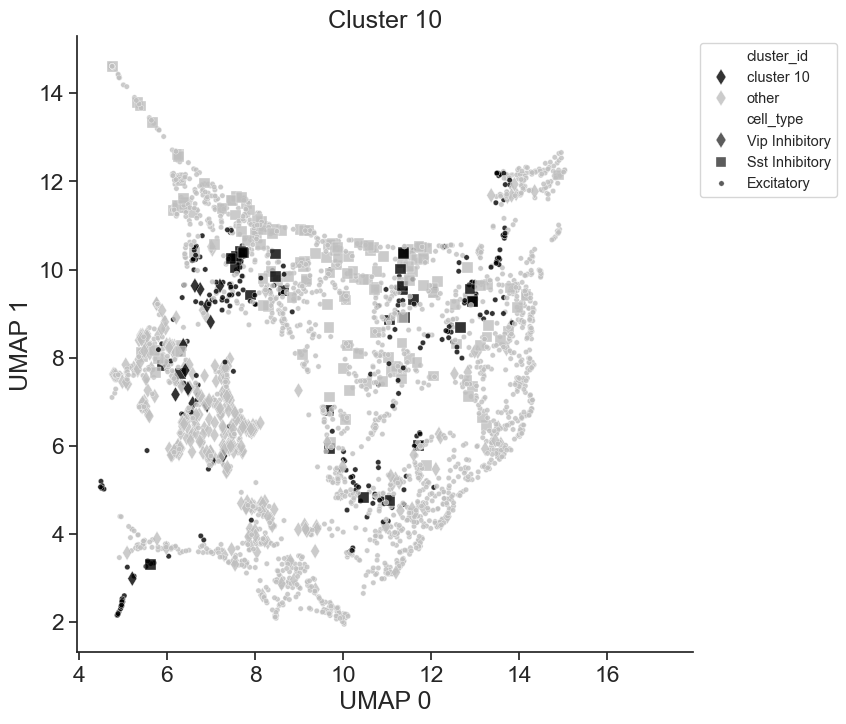

In [39]:
figsize = (8,8)
fig, ax = plt.subplots(figsize=figsize)

markers_dict = {'Excitatory': '.', # '^'
                'Sst Inhibitory': 's', # 'o', 's'
                'Vip Inhibitory': 'd'}

ax = sns.scatterplot(data=umap_df, x='x', y='y', s=60, ax=ax, #label=labels,
                     hue='cluster_id', hue_order=hue_order, style='cell_type', 
                     palette=palette, markers=markers_dict, linewidth=0.3, alpha=0.8, edgecolor='w')
ax.set_xlabel('UMAP 0')
ax.set_ylabel('UMAP 1')
ax.axis('square')
ax.legend(fontsize='xx-small', title_fontsize='xx-small',  bbox_to_anchor=(1,1))
ax.set_title('Cluster 10')

#### pie charts

In [40]:
hue_order = ['cluster 2', 'cluster 6', 'cluster 3', 'cluster 4',
             'cluster 9', 'cluster 8', 'cluster 10', 'cluster 12', 
             'other']

palette = ['#aa1016', # novelty enhanced - red #AB0F15, #aa1016 
           '#55a868', # novelty suppressed - light red #E38686, #fc8161, pink #E68C8F, green #55a868
            '#572c92', # novel image coding -  purple #A2258F, #572c92
            '#0b559f', # familiar image coding - blue #0B549D, #0b559f 
            '#8d89c0', # omission coding during novel+ - light purple #9A79C9, #afaed4
            '#539ecd', # omission coding during familiar - light blue #71A9DE, #89bedc 
            '#ccb974', # task coding during familiar - yellow #DBD689
            '#dd8452', # behavior coding - orange #FAB171
            '#BFBFBF',] # non coding - gray #BFBFBF


In [41]:
labels_dict = {1: 'non-coding', # non coding - gray
                2: 'novelty enhanced', # novel image coding - red #AB0F15
                3: 'novel image coding', # persistent novel image coding -  reddish purple #A2258F
                4: 'familiar image coding', # familiar image coding - blue #0B549D
                5: 'novel image coding', # weird coding -reddish purple
                6: 'novelty suppressed', # novelty suppression - light red #E38686
                7: 'unselective', # everything coding gray
                8: 'familiar omission coding', # omission coding during familiar - light blue #71A9DE
                9: 'novel+ omission coding', # omission coding during novel+ - light purple #9A79C9
                10: 'task coding', # task coding during familiar - yellow #DBD689
                11: 'task coding', # task coding during novel - gray
                12: 'behavior coding', # behavior coding - orange #FAB171
                }
labels = [labels_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]


In [42]:
hue_order = umap_df.cluster_label.unique()
hue_order = [ 'novelty enhanced', 'novelty suppressed',
             'novel image coding', 'familiar image coding', 
             'novel+ omission coding','familiar omission coding', 
             'task coding', 'behavior coding', 'unselective', 'non-coding']

palette = ['#aa1016', # novelty enhanced - red #AB0F15, #aa1016 
           '#55a868', # novelty suppressed - light red #E38686, #fc8161, pink #E68C8F, green #55a868
            '#572c92', # novel image coding -  purple #A2258F, #572c92
            '#0b559f', # familiar image coding - blue #0B549D, #0b559f 
            '#8d89c0', # omission coding during novel+ - light purple #9A79C9, #afaed4
            '#539ecd', # omission coding during familiar - light blue #71A9DE, #89bedc 
            '#ccb974', # task coding during familiar - yellow #DBD689
            '#dd8452', # behavior coding - orange #FAB171
            '#BFBFBF', # unselective
            '#BFBFBF',] # non-coding - gray #BFBFBF


In [43]:
# get saved umap results
umap_df = processing.get_umap_results(feature_matrix, cluster_meta, save_dir=data_dir, suffix='')
umap_df['cell_specimen_id'] = cluster_meta.index.values
umap_df = umap_df.set_index('cell_specimen_id')

umap_df['cluster_id'] = [cluster_meta.loc[cell_specimen_id]['cluster_id'] for cell_specimen_id in cluster_meta.index.values]
umap_df['cluster_label'] = [labels_dict[cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in cluster_meta.index.values]
umap_df['cluster_id'] = ['cluster '+str(cluster_meta.loc[cell_specimen_id]['cluster_id']) for cell_specimen_id in cluster_meta.index.values]
umap_df['cell_type'] = [cell_type for cell_type in cluster_meta.cell_type.values]
umap_df.head()

loading umap results from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_clustering_results/umap_results_df.h5


,x,y,cluster_id,cluster_label,cell_type
cell_specimen_id,,,,,
1086489847,4.780380,7.625232,cluster 12,behavior coding,Vip Inhibitory
1086489860,9.371953,2.737884,cluster 2,novelty enhanced,Vip Inhibitory
1086489891,4.785028,7.619345,cluster 12,behavior coding,Vip Inhibitory
1086489976,6.144250,11.332527,cluster 4,familiar image coding,Sst Inhibitory
1086490002,9.028252,10.901272,cluster 4,familiar image coding,Sst Inhibitory


In [44]:
cluster_counts = umap_df.groupby(['cell_type', 'cluster_label']).count().rename(columns={'cluster_id':'n_cluster'})[['n_cluster']].reset_index()
cre_counts = umap_df.groupby(['cell_type']).count().rename(columns={'cluster_id':'n_cre'})[['n_cre']].reset_index()
counts = cluster_counts.merge(cre_counts, on='cell_type')
counts['fraction'] = counts['n_cluster']/counts['n_cre']
counts

,cell_type,cluster_label,n_cluster,n_cre,fraction
0,Excitatory,behavior coding,128,3298,0.038811
1,Excitatory,familiar image coding,313,3298,0.094906
2,Excitatory,familiar omission coding,25,3298,0.007580
3,Excitatory,non-coding,722,3298,0.218921
4,Excitatory,novel image coding,687,3298,0.208308
5,Excitatory,novel+ omission coding,29,3298,0.008793
6,Excitatory,novelty enhanced,611,3298,0.185264
7,Excitatory,novelty suppressed,177,3298,0.053669
8,Excitatory,task coding,402,3298,0.121892
9,Excitatory,unselective,204,3298,0.061856


In [45]:
hue_order = [ 'novelty enhanced', 'novelty suppressed',
             'novel image coding', 'familiar image coding', 
             'novel+ omission coding','familiar omission coding', 
             'task coding', 'behavior coding', 'unselective', 'non-coding']

In [46]:
cell_type = 'Vip Inhibitory'

data = counts[counts.cell_type==cell_type]

fractions = []
colors = []
cluster_labels = []
for i, cluster_label in enumerate(hue_order): 
    tmp = data[data.cluster_label==cluster_label]
    if len(tmp)>0: 
        fractions.append(tmp.fraction.values[0])
        colors.append(palette[i])
        cluster_labels.append(cluster_label.replace(' ','\n'))


In [47]:
cluster_labels[3].replace(' ','\n')

'familiar\nomission\ncoding'

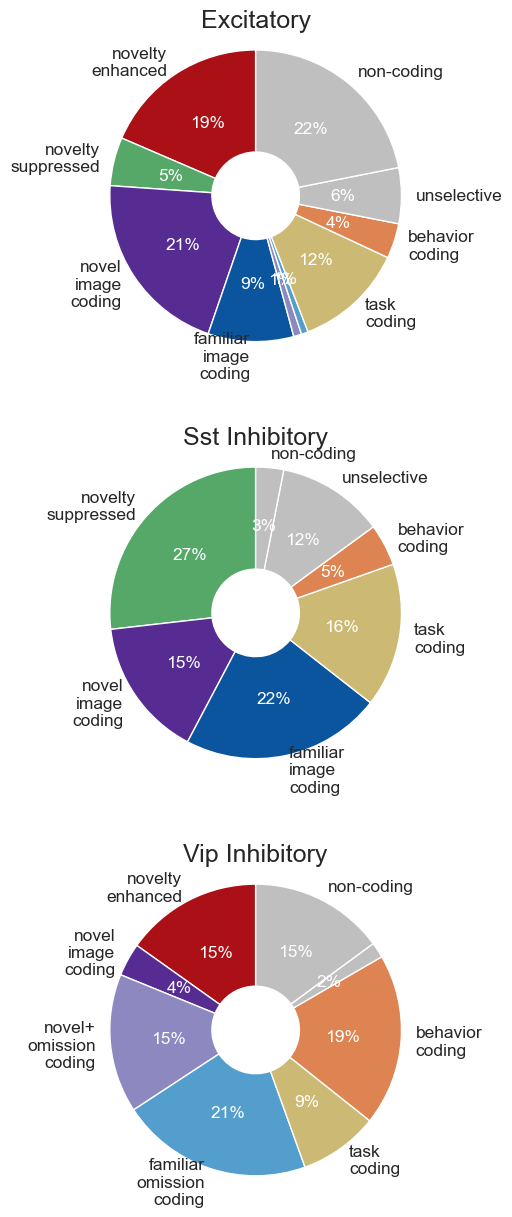

In [48]:
figsize = (5, 15)
fig, ax = plt.subplots(3, 1, figsize=figsize)

for i, cell_type in enumerate(cell_types): 
    # get data for this cell type, with cluster labels & colors in a specific order
    data = counts[counts.cell_type==cell_type]
    fractions = []
    colors = []
    cluster_labels = []
    for c, cluster_label in enumerate(hue_order): 
        tmp = data[data.cluster_label==cluster_label]
        if len(tmp)>0: 
            fractions.append(tmp.fraction.values[0])
            colors.append(palette[c])
            if tmp.fraction.values[0]<=0.03: 
                label = ''
            else: 
                label = cluster_label.replace(' ','\n')
            cluster_labels.append(label)

    # plot it 
    wedges, texts, autotexts = ax[i].pie(fractions, 
                                        labels=cluster_labels, 
                                        autopct='%.0f%%',
                                        startangle=90, 
                                        wedgeprops={'width': 0.7, 'edgecolor': 'white'},   
                                        textprops={'size': 'x-small'},
                                        colors=colors) # Use a Seaborn color palette
    ax[i].axis('equal') 
    ax[i].set_title(cell_type)
    for autotext in autotexts:
        autotext.set_color('white')

    # Equal aspect ratio ensures that pie is drawn as a circle.
plt.subplots_adjust(hspace=0.3)

### Proportion cells per area and depth for meaningfully named clusters

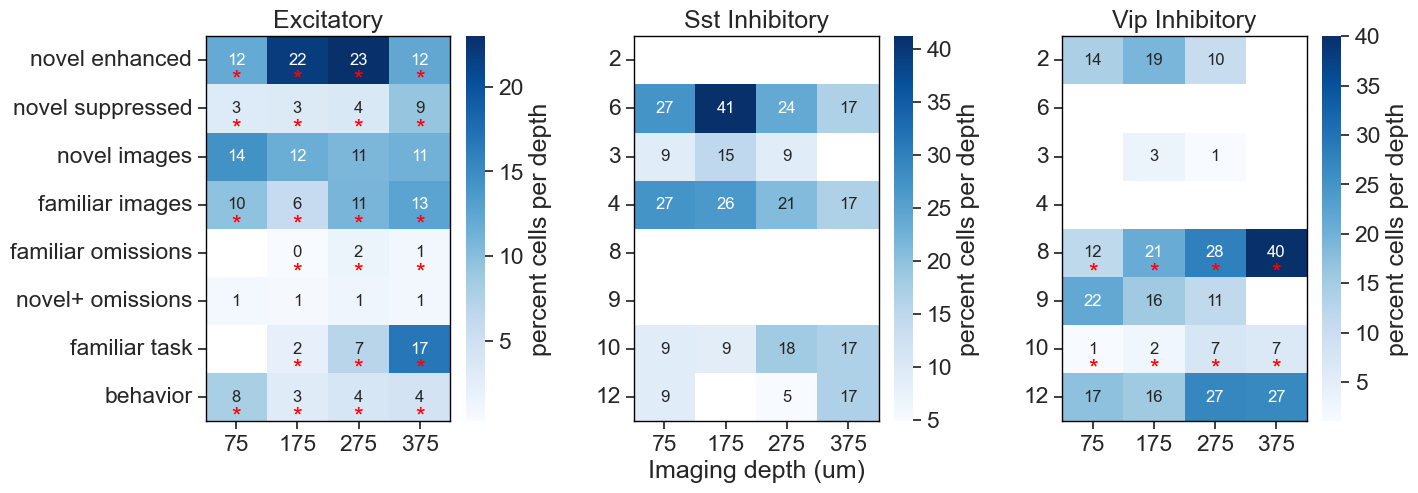

In [49]:
clusters_to_keep = [2, 6, 3, 4, 8, 9, 10, 12]
cluster_names = ['novel enhanced', 'novel suppressed',
                 'novel images', 'familiar images',  
                 'familiar omissions', 'novel+ omissions', 
                 'familiar task', 'behavior']
n_cells_table_tmp = n_cells_table[n_cells_table.cluster_id.isin(clusters_to_keep)]


fig, ax = plt.subplots(1,3, figsize=(15,5), sharey=False)
ax = ax.ravel()
for i, cre_line in enumerate(cre_lines): 
    cell_type = utils.convert_cre_line_to_cell_type(cre_line)
    pivot = get_pivoted_data_for_cell_counts(n_cells_table_tmp, cre_line, value='percent_cells_location', cluster_ids=clusters_to_keep)
    ax[i] = sns.heatmap(pivot, cmap='Blues', ax=ax[i], annot=True, fmt=".0f", annot_kws={"fontsize": 12},
                        cbar_kws={'label':'percent cells per depth'})
    pivot_sig = get_pivoted_data_for_cell_counts(n_cells_table_tmp, cre_line, value='bh_significant', cluster_ids=clusters_to_keep)
    rows, cols = np.where(pivot_sig==1)
    coords = list(zip(rows, cols))
    for coord in coords: 
        ax[i].text(s='*',y=coord[0]+0.7, x=coord[1]+0.5, ha='center', va='top', color='r')
    ax[i].set_ylabel('')
    if i == 0:
        ax[i].set_yticklabels(cluster_names, rotation=0)
    else: 
        ax[i].set_yticklabels(clusters_to_keep, rotation=0)
    ax[i].set_xlabel('')
    ax[i].set_title(cell_type)
# ax[0].set_ylabel('Cluster ID')
ax[1].set_xlabel('Imaging depth (um)')
for i in range(3):
    for _, spine in ax[i].spines.items():
        spine.set_visible(True)
        spine.set_color('black')  # Set the color of the box
        spine.set_linewidth(1)  
fig.subplots_adjust(wspace=0.4)

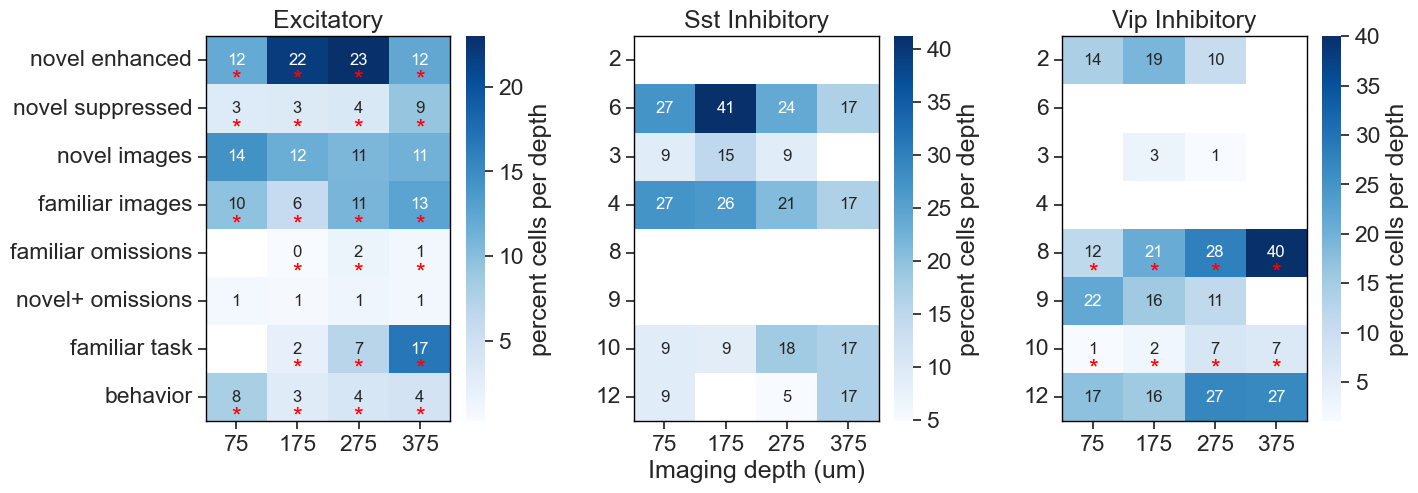

In [50]:
clusters_to_keep = [2, 6, 3, 4, 8, 9, 10, 12]
cluster_names = ['novel enhanced', 'novel suppressed',
                 'novel images', 'familiar images',  
                 'familiar omissions', 'novel+ omissions', 
                 'familiar task', 'behavior']
n_cells_table_tmp = n_cells_table[n_cells_table.cluster_id.isin(clusters_to_keep)]


fig, ax = plt.subplots(1,3, figsize=(15,5), sharey=False)
ax = ax.ravel()
for i, cre_line in enumerate(cre_lines): 
    cell_type = utils.convert_cre_line_to_cell_type(cre_line)
    pivot = get_pivoted_data_for_cell_counts(n_cells_table_tmp, cre_line, value='percent_cells_location', cluster_ids=clusters_to_keep)
    ax[i] = sns.heatmap(pivot, cmap='Blues', ax=ax[i], annot=True, fmt=".0f", annot_kws={"fontsize": 12},
                        cbar_kws={'label':'percent cells per depth'})
    pivot_sig = get_pivoted_data_for_cell_counts(n_cells_table_tmp, cre_line, value='bh_significant', cluster_ids=clusters_to_keep)
    rows, cols = np.where(pivot_sig==1)
    coords = list(zip(rows, cols))
    for coord in coords: 
        ax[i].text(s='*',y=coord[0]+0.7, x=coord[1]+0.5, ha='center', va='top', color='r')
    ax[i].set_ylabel('')
    if i == 0:
        ax[i].set_yticklabels(cluster_names, rotation=0)
    else: 
        ax[i].set_yticklabels(clusters_to_keep, rotation=0)
    ax[i].set_xlabel('')
    ax[i].set_title(cell_type)
# ax[0].set_ylabel('Cluster ID')
ax[1].set_xlabel('Imaging depth (um)')
for i in range(3):
    for _, spine in ax[i].spines.items():
        spine.set_visible(True)
        spine.set_color('black')  # Set the color of the box
        spine.set_linewidth(1)  
fig.subplots_adjust(wspace=0.4)

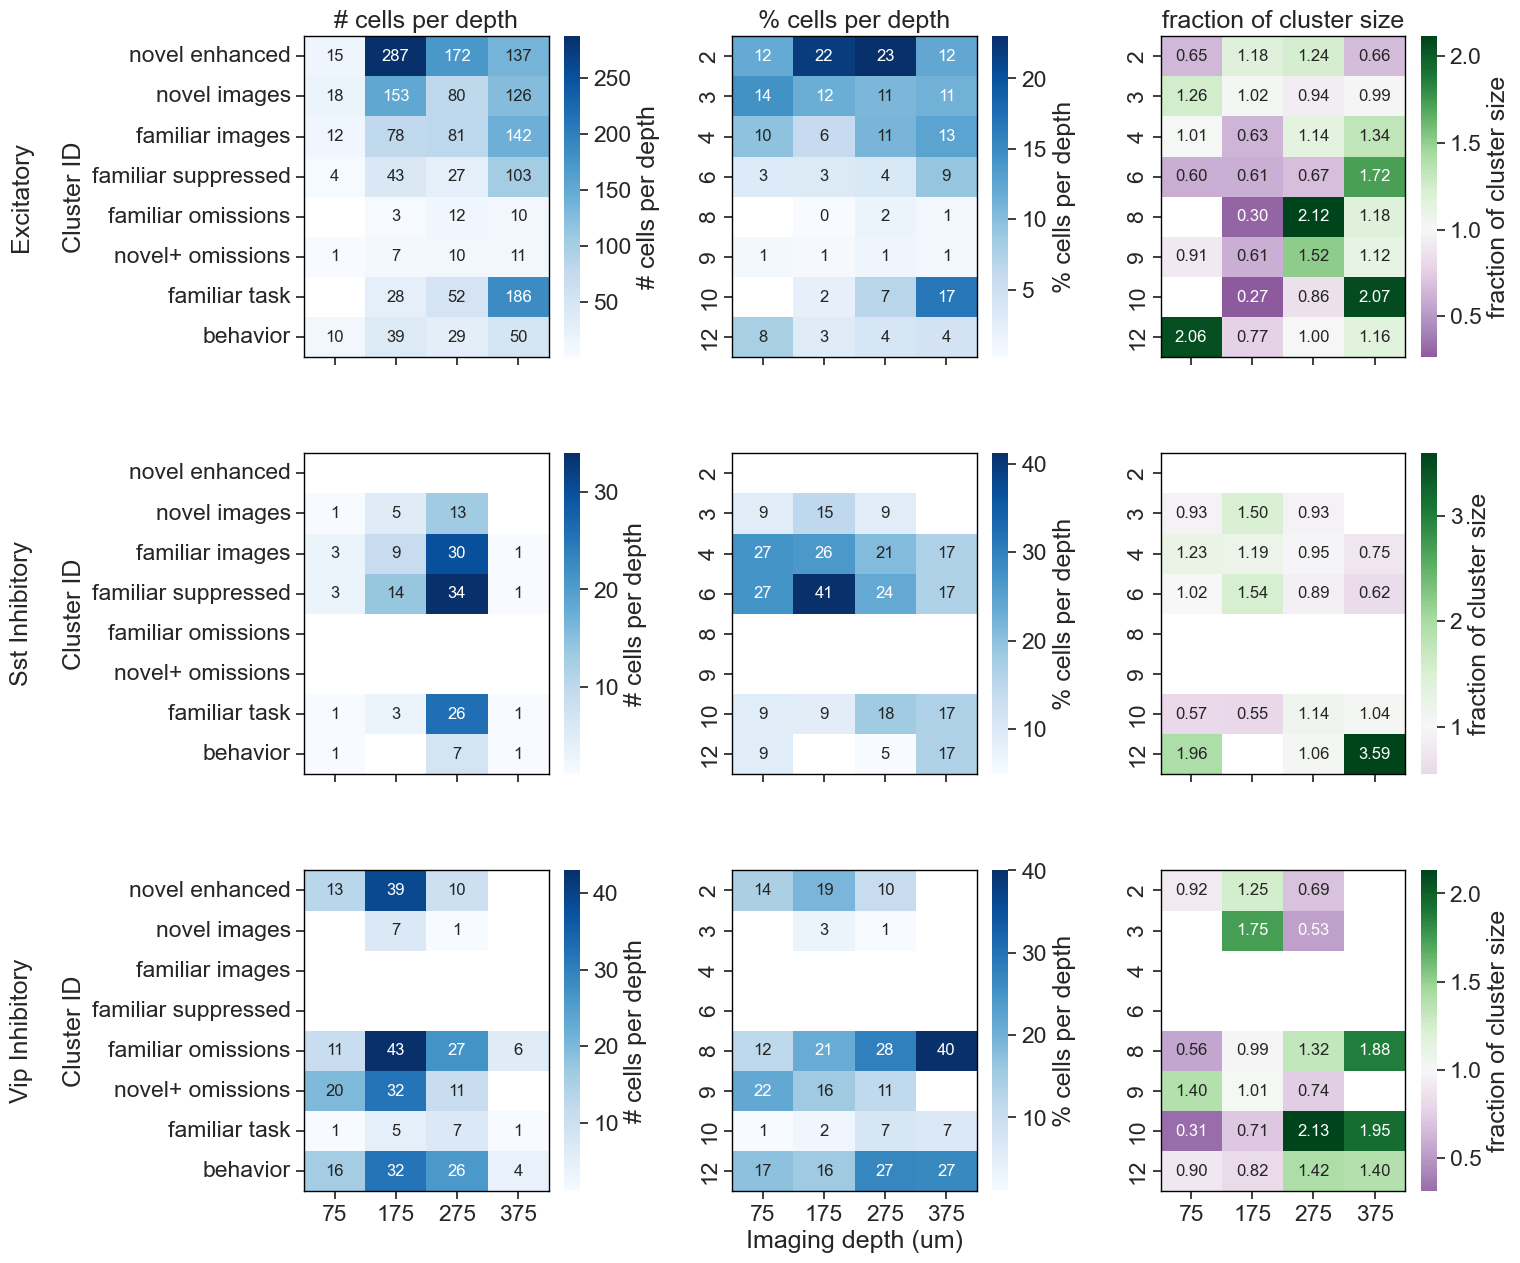

In [51]:
clusters_to_keep = [2, 3, 4, 6, 8, 9, 10, 12]
cluster_names = ['novel enhanced', 'novel images', 'familiar images', 'familiar suppressed', 
                 'familiar omissions', 'novel+ omissions', 'familiar task', 'behavior']
n_cells_table_tmp = n_cells_table[n_cells_table.cluster_id.isin(clusters_to_keep)]

fig, ax = plt.subplots(3, 3, figsize=(15, 15), sharey=False, sharex=True)
ax = ax.ravel()
i=0
for c, cre_line in enumerate(cre_lines): 
    cell_type = utils.convert_cre_line_to_cell_type(cre_line)
    pivot = get_pivoted_data_for_cell_counts(n_cells_table, cre_line, value='n_cells_location', cluster_ids=clusters_to_keep)
    pivot.index = cluster_names
    ax[i] = sns.heatmap(pivot, cmap='Blues', ax=ax[i], annot=True, fmt=".0f", annot_kws={"fontsize": 12},
                        cbar_kws={'label':'# cells per depth'})
    ax[i].set_ylabel(cell_type+'\n\nCluster ID')
    ax[i].set_yticklabels(cluster_names, rotation=0)
    if c==0: 
        ax[i].set_title('# cells per depth')
    i+=1
    pivot = get_pivoted_data_for_cell_counts(n_cells_table, cre_line, value='percent_cells_location', cluster_ids=clusters_to_keep)
    ax[i] = sns.heatmap(pivot, cmap='Blues', ax=ax[i], annot=True, fmt=".0f", annot_kws={"fontsize": 12},
                        cbar_kws={'label':'% cells per depth'})
    ax[i].set_ylabel('')
    if c==0: 
        ax[i].set_title('% cells per depth')
    i+=1
    pivot = get_pivoted_data_for_cell_counts(n_cells_table, cre_line, value='fraction_of_cluster_size', cluster_ids=clusters_to_keep)
    ax[i] = sns.heatmap(pivot, cmap='PRGn', center=1, ax=ax[i], annot=True, fmt=".2f", annot_kws={"fontsize": 12},
                        cbar_kws={'label':'fraction of cluster size'})
    ax[i].set_ylabel('')
    if c==0: 
        ax[i].set_title('fraction of cluster size')
    i+=1

for i in range(9):
    ax[i].set_xlabel('') 
    for _, spine in ax[i].spines.items():
        spine.set_visible(True)
        spine.set_color('black')  # Set the color of the box
        spine.set_linewidth(1)   
ax[7].set_xlabel('Imaging depth (um)')
fig.subplots_adjust(hspace=0.3, wspace=0.4)

### Single cell examples

cell_specimen_id: 1086514606
experience_level: Familiar
ophys_experiment_id: 989213060


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel
ophys_experiment_id: 990400778


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel +
ophys_experiment_id: 991852002


...

experience_level: Novel
ophys_experiment_id: 990400778


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is 

experience_level: Novel +
ophys_experiment_id: 991852002


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is 

saving plot for 1086514606
saved


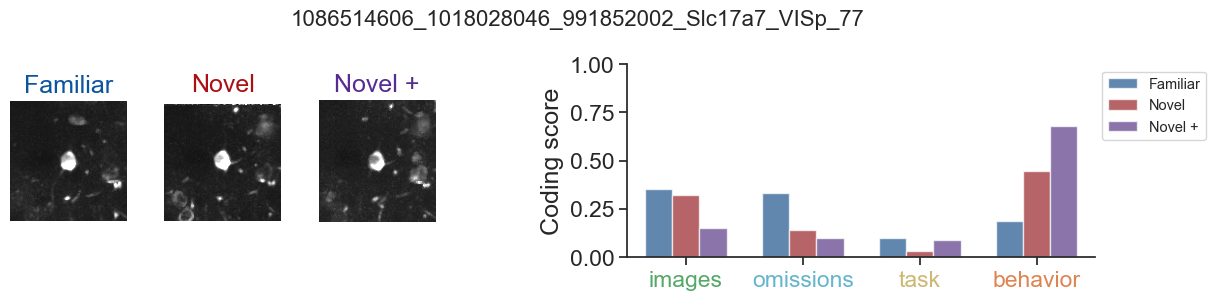

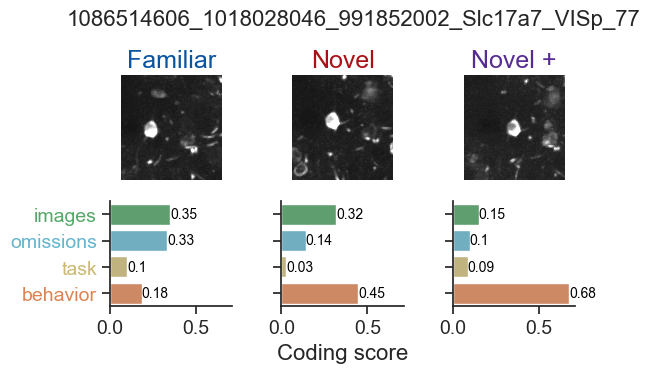

In [52]:
# cell_specimen_id = 1086515505
cell_specimen_id = 1086514606 #Excitatory behavior coding cell

cell_metadata = platform_cells_table[platform_cells_table.cell_specimen_id == cell_specimen_id]
cell_dropouts = results_pivoted[results_pivoted.cell_specimen_id==cell_specimen_id][processing.get_features_for_clustering()+['experience_level']]

# Load change and omission response dataframes for example cell
change_mdf_example = change_mdf[change_mdf.cell_specimen_id == cell_specimen_id]
omission_mdf_example = omission_mdf[omission_mdf.cell_specimen_id == cell_specimen_id]

# Plot matched ROI and coding scores
pse.plot_matched_roi_and_coding_scores(cell_metadata, cell_dropouts, platform_experiments, 
                                       save_dir=save_dir)
pse.plot_matched_roi_and_coding_scores_for_experience_levels(cell_metadata, cell_dropouts, platform_experiments, 
                                       save_dir=save_dir)

# # Plot cell change and omission responses
# pse.plot_cell_change_and_omission_responses(
#     change_mdf_example,
#     omission_mdf_example,
#     cell_specimen_id,
#     save_dir=save_dir)

cell_specimen_id: 1086620671
experience_level: Familiar
ophys_experiment_id: 956941846


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel
ophys_experiment_id: 957759566


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel +
ophys_experiment_id: 960410028


...

experience_level: Novel
ophys_experiment_id: 957759566


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is 

experience_level: Novel +
ophys_experiment_id: 960410028


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is 

saving plot for 1086620671
saved


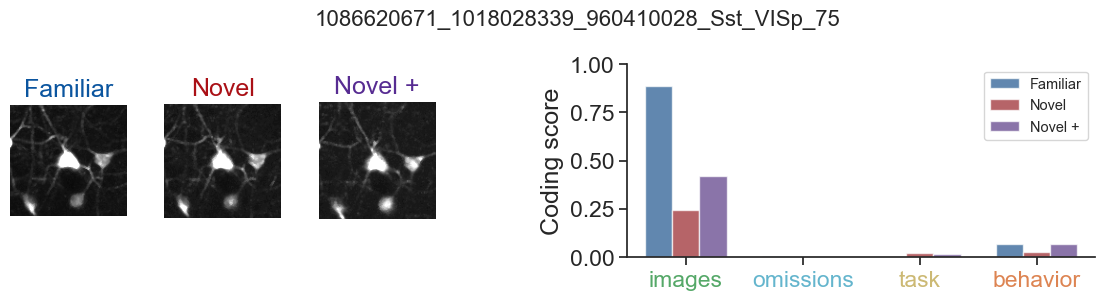

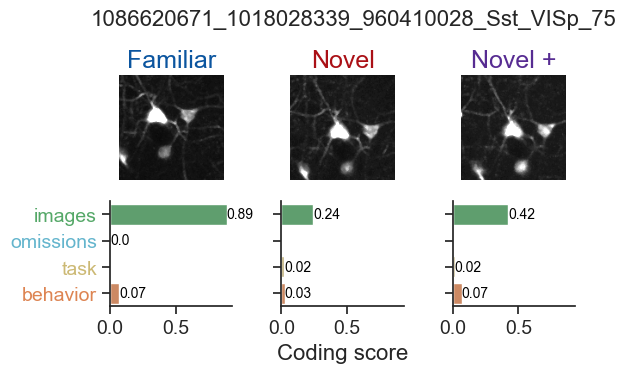

In [53]:
# Get cell response dataframes for example cell
cell_specimen_id = 1086620671  
cell_metadata = platform_cells_table[platform_cells_table.cell_specimen_id == cell_specimen_id]
cell_dropouts = results_pivoted[results_pivoted.cell_specimen_id==cell_specimen_id][processing.get_features_for_clustering()+['experience_level']]

# Load change and omission response dataframes for example cell
change_mdf_example = change_mdf[change_mdf.cell_specimen_id == cell_specimen_id]
omission_mdf_example = omission_mdf[omission_mdf.cell_specimen_id == cell_specimen_id]

# Plot matched ROI and coding scores
pse.plot_matched_roi_and_coding_scores(cell_metadata, cell_dropouts, platform_experiments, 
                                       save_dir=save_dir)
pse.plot_matched_roi_and_coding_scores_for_experience_levels(cell_metadata, cell_dropouts, platform_experiments, 
                                       save_dir=save_dir)

# # Plot cell change and omission responses
# pse.plot_cell_change_and_omission_responses(
#     change_mdf_example,
#     omission_mdf_example,
#     cell_specimen_id,
#     save_dir=save_dir)


cell_specimen_id: 1086628708
experience_level: Familiar
ophys_experiment_id: 882551935


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel
ophys_experiment_id: 882968564


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel +
ophys_experiment_id: 885146239


...

experience_level: Novel
ophys_experiment_id: 882968564


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is 

experience_level: Novel +
ophys_experiment_id: 885146239


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is 

saving plot for 1086628708
saved


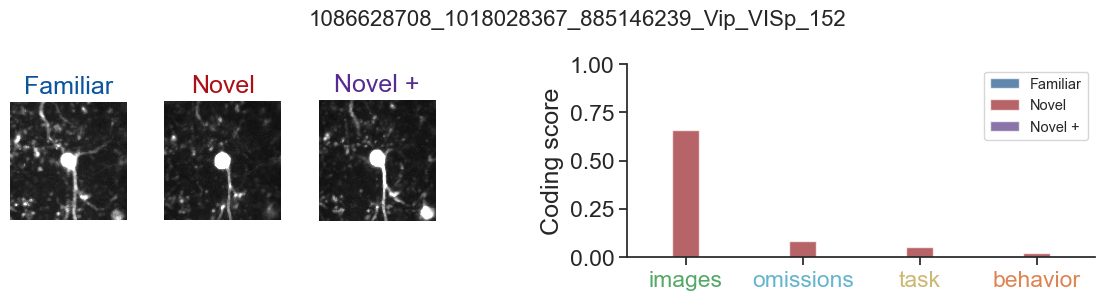

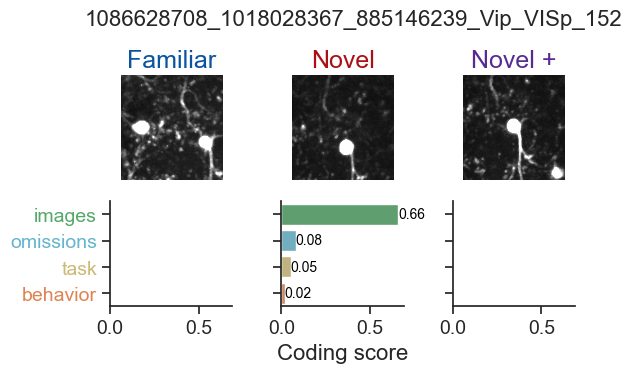

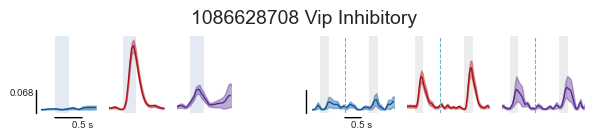

In [54]:
# Get cell response dataframes for example cell
cell_specimen_id = 1086628708  
cell_metadata = platform_cells_table[platform_cells_table.cell_specimen_id == cell_specimen_id]
cell_dropouts = results_pivoted[results_pivoted.cell_specimen_id==cell_specimen_id][processing.get_features_for_clustering()+['experience_level']]

# Load change and omission response dataframes for example cell
change_mdf_example = change_mdf[change_mdf.cell_specimen_id == cell_specimen_id]
omission_mdf_example = omission_mdf[omission_mdf.cell_specimen_id == cell_specimen_id]

# Plot matched ROI and coding scores
pse.plot_matched_roi_and_coding_scores(cell_metadata, cell_dropouts, platform_experiments, 
                                       save_dir=save_dir)
pse.plot_matched_roi_and_coding_scores_for_experience_levels(cell_metadata, cell_dropouts, platform_experiments, 
                                       save_dir=save_dir)

# Plot cell change and omission responses
pse.plot_cell_change_and_omission_responses(
    change_mdf_example,
    omission_mdf_example,
    cell_specimen_id,
    save_dir=save_dir)


### Graphical abstract

In [55]:
import umap

In [56]:
umap_df = processing.get_umap_results(feature_matrix, cluster_meta, save_dir=data_dir, suffix='')

loading umap results from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_clustering_results/umap_results_df.h5


In [57]:
# limit cluster meta to cells that are not in cluster 1 (which is an outlier in the plot)
main_cluster_meta = cluster_meta[cluster_meta.cluster_id!=1]
# limit umap_df to non-cluster 1
umap_df['cell_specimen_id'] = cluster_meta.index.values
umap_df = umap_df.set_index('cell_specimen_id')
umap_df = umap_df.loc[main_cluster_meta.index.values]
umap_df['cell_type'] = main_cluster_meta['cell_type']
# identify other non-outlier points and limit both tables to those
csids = umap_df[umap_df.x<16].index.values
main_cluster_meta = main_cluster_meta.loc[csids]
umap_df = umap_df.loc[csids]
print(len(umap_df), len(main_cluster_meta))
umap_df.head()

2941 2941


,x,y,cluster_id,cell_type
cell_specimen_id,,,,
1086489847,4.780380,7.625232,12,Vip Inhibitory
1086489860,9.371953,2.737884,2,Vip Inhibitory
1086489891,4.785028,7.619345,12,Vip Inhibitory
1086489976,6.144250,11.332527,4,Sst Inhibitory
1086490002,9.028252,10.901272,4,Sst Inhibitory


In [58]:
exp_colors = utils.get_experience_level_colors()
gray = (0.8, 0.8, 0.8)
cluster_color_dict = {1: gray, # non coding - gray
                      2: exp_colors[1], # novel image coding - red
                      3: exp_colors[2], # persistent novel image coding - purple 
                      4: exp_colors[0], # familiar image coding - blue
                      5: exp_colors[2], # novel+ image coding - purple 
                      6: exp_colors[2], # novelty suppression - purple
                      7: exp_colors[1], # novel image (+familiar) coding - red
                      8: exp_colors[0], # omission coding during familiar - blue
                      9: exp_colors[2], # omission coding during novel+ - purple
                      10: exp_colors[0], # task coding during familiar - blue
                      11: exp_colors[1], # novel task coding - red
                      12: gray, # behavior coding - gray
                      }
exp_colors = [cluster_color_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]


feature_colors = plotting.get_feature_colors_with_gray()
feature_color_dict = {1: gray, # non coding - gray
                      2: feature_colors[1], # image coding
                      3: feature_colors[1], # image coding
                      4: feature_colors[1], # image coding
                      5: feature_colors[1], # image coding 
                      6: feature_colors[1], # image coding 
                      7: feature_colors[1], # image coding 
                      8: feature_colors[2], # omission coding
                      9: feature_colors[2], # omission coding
                      10: feature_colors[3], # task coding
                      11: feature_colors[3], # task coding
                      12: feature_colors[4], # behavior coding
                      }

feature_colors = [feature_color_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]

meaningful_labels_dict = {1: '', # non coding - gray
                2: 'novelty enhanced', # novel image coding - red
                3: 'novel image coding', # persistent novel image coding - purple 
                4: 'familiar image coding', # familiar image coding - blue
                5: '', # weird coding - gray
                6: 'novelty suppressed', # novelty suppression - purple
                7: '', # everything coding gray
                8: 'omission coding', # omission coding during familiar - blue
                9: 'omission coding', # omission coding during novel+ - purple
                10: 'task coding', # task coding during familiar - blue
                11: '', # task coding during novel - gray
                12: 'behavior coding', # behavior coding - gray
                }
meaningful_labels = [meaningful_labels_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]


markers_dict = {'Exc': 'o', # '^'
                'Sst': 's', # 'o'
                'Vip': 'd'}

markers = [markers_dict[main_cluster_meta.loc[cell_specimen_id]['cell_type'][:3]] for cell_specimen_id in main_cluster_meta.index.values]

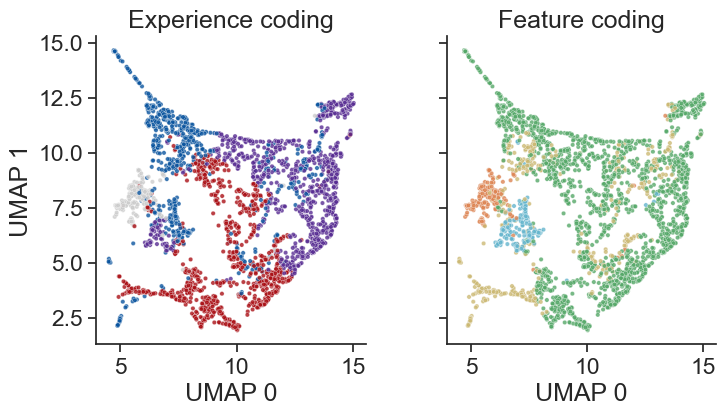

In [59]:
figsize = (8, 4)

fig, ax = plt.subplots(1, 2, figsize=figsize, sharex=True, sharey=True)

umap_df['labels'] = meaningful_labels
ax[0] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[0], #label=labels,
                     color=exp_colors, markers=markers, alpha=0.8)
ax[0].set_title('Experience coding')
ax[1] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[1], #label=labels,
                     color=feature_colors, markers=markers, alpha=0.8)
ax[1].set_title('Feature coding')
ax[0].set_xlabel('UMAP 0')
ax[1].set_xlabel('UMAP 0')
ax[0].set_ylabel('UMAP 1')
plt.subplots_adjust(wspace=0.3)

/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_6860/1518427512.py:23: UserWarning: 
The palette list has fewer values (10) than needed (11) and will cycle, which may produce an uninterpretable plot.
  ax[2] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[2], #label=labels,


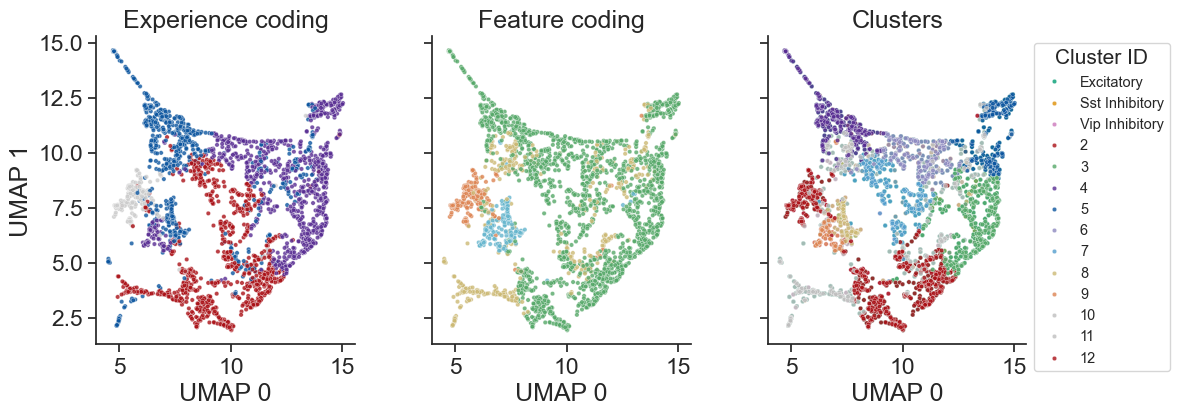

In [60]:
figsize = (12, 4)

fig, ax = plt.subplots(1, 3, figsize=figsize, sharex=True, sharey=True)

ax[0] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[0], #label=labels,
                     color=exp_colors, markers=markers, alpha=0.8)
ax[0].set_title('Experience coding')
ax[1] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[1], #label=labels,
                     color=feature_colors, markers=markers, alpha=0.8)
ax[1].set_title('Feature coding')
ax[0].set_xlabel('UMAP 0')
ax[1].set_xlabel('UMAP 0')
ax[0].set_ylabel('UMAP 1')

ax[2] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[2], hue_order=cell_types,
                     hue='cell_type', markers=markers, palette=utils.get_cell_type_colors(), alpha=0.8)
ax[2].set_title('Cell types')
ax[2].set_xlabel('UMAP 0')
ax[2].set_ylabel('UMAP 1')
ax[2].legend(title='Cell type', bbox_to_anchor=(1, 1), fontsize='xx-small', title_fontsize='small')
plt.subplots_adjust(wspace=0.3)

ax[2] = sns.scatterplot(data=umap_df, x='x', y='y', s=10, ax=ax[2], #label=labels,
                     hue='cluster_id', markers=markers, palette=palette, alpha=0.8)
ax[2].set_title('Clusters')
ax[2].set_xlabel('UMAP 0')
ax[2].set_ylabel('UMAP 1')
ax[2].legend(title='Cluster ID', bbox_to_anchor=(1, 1), fontsize='xx-small', title_fontsize='small')
plt.subplots_adjust(wspace=0.3)

#### Try with new colors for specific cluster types

In [61]:
cluster_id_labels = ['cluster '+str(main_cluster_meta.loc[cell_specimen_id]['cluster_id']) for cell_specimen_id in main_cluster_meta.index.values]

labels_dict = {1: 'other', # non coding - gray
                2: 'novelty enhanced', # novel image coding - red #AB0F15
                3: 'novel image coding', # persistent novel image coding -  reddish purple #A2258F
                4: 'familiar image coding', # familiar image coding - blue #0B549D
                5: 'other', # weird coding - gray
                6: 'novelty suppressed', # novelty suppression - light red #E38686
                7: 'other', # everything coding gray
                8: 'familiar omission coding', # omission coding during familiar - light blue #71A9DE
                9: 'novel+ omission coding', # omission coding during novel+ - light purple #9A79C9
                10: 'task coding', # task coding during familiar - yellow #DBD689
                11: 'other', # task coding during novel - gray
                12: 'behavior coding', # behavior coding - orange #FAB171
                }
labels = [labels_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]


# gray = #BFBFBF
clutster_colors_dict = {1: '#BFBFBF', # non coding - gray #BFBFBF
                2: '#AB0F15', # novel image coding - red #AB0F15
                3: '#A2258F', # persistent novel image coding -  reddish purple #A2258F
                4: '#0B549D', # familiar image coding - blue #0B549D
                5: '#BFBFBF', # weird coding - gray
                6: '#E38686', # novelty suppression - light red #E38686
                7: '#BFBFBF', # everything coding gray
                8: '#71A9DE', # omission coding during familiar - light blue #71A9DE
                9: '#9A79C9', # omission coding during novel+ - light purple #9A79C9
                10: '#DBD689', # task coding during familiar - yellow #DBD689
                11: '#BFBFBF', # task coding during novel - gray
                12: '#FAB171', # behavior coding - orange #FAB171
                }
new_colors = [clutster_colors_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]


markers_dict = {'Exc': 'o', # '^'
                'Sst': 's', # 'o'
                'Vip': 'd'}

markers = [markers_dict[main_cluster_meta.loc[cell_specimen_id]['cell_type'][:3]] for cell_specimen_id in main_cluster_meta.index.values]

In [62]:
umap_df['cluster_id'] = [main_cluster_meta.loc[cell_specimen_id]['cluster_id'] for cell_specimen_id in main_cluster_meta.index.values]
umap_df['cluster_label'] = [labels_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]
umap_df['cluster_id'] = ['cluster '+str(main_cluster_meta.loc[cell_specimen_id]['cluster_id']) for cell_specimen_id in main_cluster_meta.index.values]
umap_df['cell_type'] = [cell_type for cell_type in main_cluster_meta.cell_type.values]
umap_df.head()

,x,y,cluster_id,cell_type,labels,cluster_label
cell_specimen_id,,,,,,
1086489847,4.780380,7.625232,cluster 12,Vip Inhibitory,behavior coding,behavior coding
1086489860,9.371953,2.737884,cluster 2,Vip Inhibitory,novelty enhanced,novelty enhanced
1086489891,4.785028,7.619345,cluster 12,Vip Inhibitory,behavior coding,behavior coding
1086489976,6.144250,11.332527,cluster 4,Sst Inhibitory,familiar image coding,familiar image coding
1086490002,9.028252,10.901272,cluster 4,Sst Inhibitory,familiar image coding,familiar image coding


In [63]:
red = sns.color_palette('Reds_r', 6).as_hex()[0]
blue = sns.color_palette('Blues_r', 6).as_hex()[0]
purple = sns.color_palette('Purples_r', 6).as_hex()[0]
print(red, blue, purple)

red = sns.color_palette('Reds_r', 6).as_hex()[2]
blue = sns.color_palette('Blues_r', 6).as_hex()[2]
purple = sns.color_palette('Purples_r', 6).as_hex()[2]
print(red, blue, purple)

#aa1016 #0b559f #572c92
#f44f39 #539ecd #8d89c0


In [64]:
# hue_order = umap_df.cluster_label.unique()
hue_order = [ 'novelty enhanced', 'novelty suppressed',
             'novel image coding', 'familiar image coding', 
             'novel+ omission coding','familiar omission coding', 
             'task coding', 'behavior coding', 'other']

palette = ['#aa1016', # novelty enhanced - red #AB0F15, #aa1016 
           '#55a868', # novelty suppressed - light red #E38686, #fc8161, pink #E68C8F, green #55a868
            '#572c92', # novel image coding -  purple #A2258F, #572c92
            '#0b559f', # familiar image coding - blue #0B549D, #0b559f 
            '#8d89c0', # omission coding during novel+ - light purple #9A79C9, #afaed4
            '#539ecd', # omission coding during familiar - light blue #71A9DE, #89bedc 
            '#ccb974', # task coding during familiar - yellow #DBD689
            '#dd8452', # behavior coding - orange #FAB171
            '#BFBFBF',] # non coding - gray #BFBFBF



Text(0.5, 1.0, 'Main clusters')

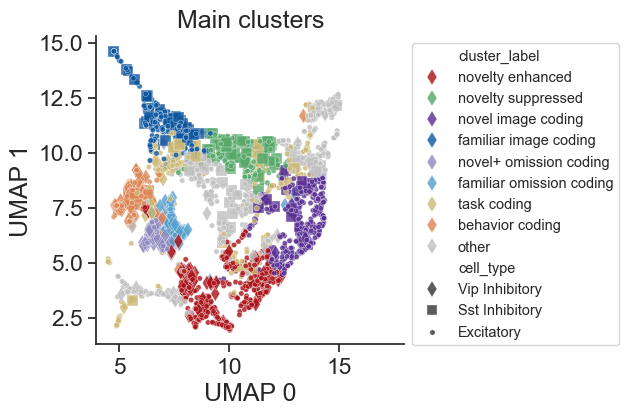

In [65]:
figsize = (7, 4)
fig, ax = plt.subplots(figsize=figsize)

markers_dict = {'Excitatory': '.', # '^'
                'Sst Inhibitory': 's', # 'o', 's'
                'Vip Inhibitory': 'd'}

ax = sns.scatterplot(data=umap_df, x='x', y='y', s=60, ax=ax, #label=labels,
                     hue='cluster_label', hue_order=hue_order, style='cell_type', 
                     palette=palette, markers=markers_dict, linewidth=0.3, alpha=0.8, edgecolor='w')
ax.set_xlabel('UMAP 0')
ax.set_ylabel('UMAP 1')
ax.axis('square')
ax.legend(fontsize='xx-small', title_fontsize='xx-small',  bbox_to_anchor=(1,1))
ax.set_title('Main clusters')

#### pie charts

In [66]:
labels_dict = {1: 'non-coding', # non coding - gray
                2: 'novelty enhanced', # novel image coding - red #AB0F15
                3: 'novel image coding', # persistent novel image coding -  reddish purple #A2258F
                4: 'familiar image coding', # familiar image coding - blue #0B549D
                5: 'novel image coding', # weird coding -reddish purple
                6: 'novelty suppressed', # novelty suppression - light red #E38686
                7: 'unselective', # everything coding gray
                8: 'familiar omission coding', # omission coding during familiar - light blue #71A9DE
                9: 'novel+ omission coding', # omission coding during novel+ - light purple #9A79C9
                10: 'task coding', # task coding during familiar - yellow #DBD689
                11: 'task coding', # task coding during novel - gray
                12: 'behavior coding', # behavior coding - orange #FAB171
                }
labels = [labels_dict[main_cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in main_cluster_meta.index.values]


In [67]:
# hue_order = umap_df.cluster_label.unique()
hue_order = [ 'novelty enhanced', 'novelty suppressed',
             'novel image coding', 'familiar image coding', 
             'novel+ omission coding','familiar omission coding', 
             'task coding', 'behavior coding', 'unselective', 'non-coding']

palette = ['#aa1016', # novelty enhanced - red #AB0F15, #aa1016 
           '#55a868', # novelty suppressed - light red #E38686, #fc8161, pink #E68C8F, green #55a868
            '#572c92', # novel image coding -  purple #A2258F, #572c92
            '#0b559f', # familiar image coding - blue #0B549D, #0b559f 
            '#8d89c0', # omission coding during novel+ - light purple #9A79C9, #afaed4
            '#539ecd', # omission coding during familiar - light blue #71A9DE, #89bedc 
            '#ccb974', # task coding during familiar - yellow #DBD689
            '#dd8452', # behavior coding - orange #FAB171
            '#BFBFBF', # unselective
            '#BFBFBF',] # non-coding - gray #BFBFBF


In [68]:
# get saved umap results
umap_df = processing.get_umap_results(feature_matrix, cluster_meta, save_dir=data_dir, suffix='')
umap_df['cell_specimen_id'] = cluster_meta.index.values
umap_df = umap_df.set_index('cell_specimen_id')

umap_df['cluster_id'] = [cluster_meta.loc[cell_specimen_id]['cluster_id'] for cell_specimen_id in cluster_meta.index.values]
umap_df['cluster_label'] = [labels_dict[cluster_meta.loc[cell_specimen_id]['cluster_id']] for cell_specimen_id in cluster_meta.index.values]
umap_df['cluster_id'] = ['cluster '+str(cluster_meta.loc[cell_specimen_id]['cluster_id']) for cell_specimen_id in cluster_meta.index.values]
umap_df['cell_type'] = [cell_type for cell_type in cluster_meta.cell_type.values]
umap_df.head()

loading umap results from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_clustering_results/umap_results_df.h5


,x,y,cluster_id,cluster_label,cell_type
cell_specimen_id,,,,,
1086489847,4.780380,7.625232,cluster 12,behavior coding,Vip Inhibitory
1086489860,9.371953,2.737884,cluster 2,novelty enhanced,Vip Inhibitory
1086489891,4.785028,7.619345,cluster 12,behavior coding,Vip Inhibitory
1086489976,6.144250,11.332527,cluster 4,familiar image coding,Sst Inhibitory
1086490002,9.028252,10.901272,cluster 4,familiar image coding,Sst Inhibitory


In [69]:
cluster_counts = umap_df.groupby(['cell_type', 'cluster_label']).count().rename(columns={'cluster_id':'n_cluster'})[['n_cluster']].reset_index()
cre_counts = umap_df.groupby(['cell_type']).count().rename(columns={'cluster_id':'n_cre'})[['n_cre']].reset_index()
counts = cluster_counts.merge(cre_counts, on='cell_type')
counts['fraction'] = counts['n_cluster']/counts['n_cre']
counts

,cell_type,cluster_label,n_cluster,n_cre,fraction
0,Excitatory,behavior coding,128,3298,0.038811
1,Excitatory,familiar image coding,313,3298,0.094906
2,Excitatory,familiar omission coding,25,3298,0.007580
3,Excitatory,non-coding,722,3298,0.218921
4,Excitatory,novel image coding,687,3298,0.208308
5,Excitatory,novel+ omission coding,29,3298,0.008793
6,Excitatory,novelty enhanced,611,3298,0.185264
7,Excitatory,novelty suppressed,177,3298,0.053669
8,Excitatory,task coding,402,3298,0.121892
9,Excitatory,unselective,204,3298,0.061856


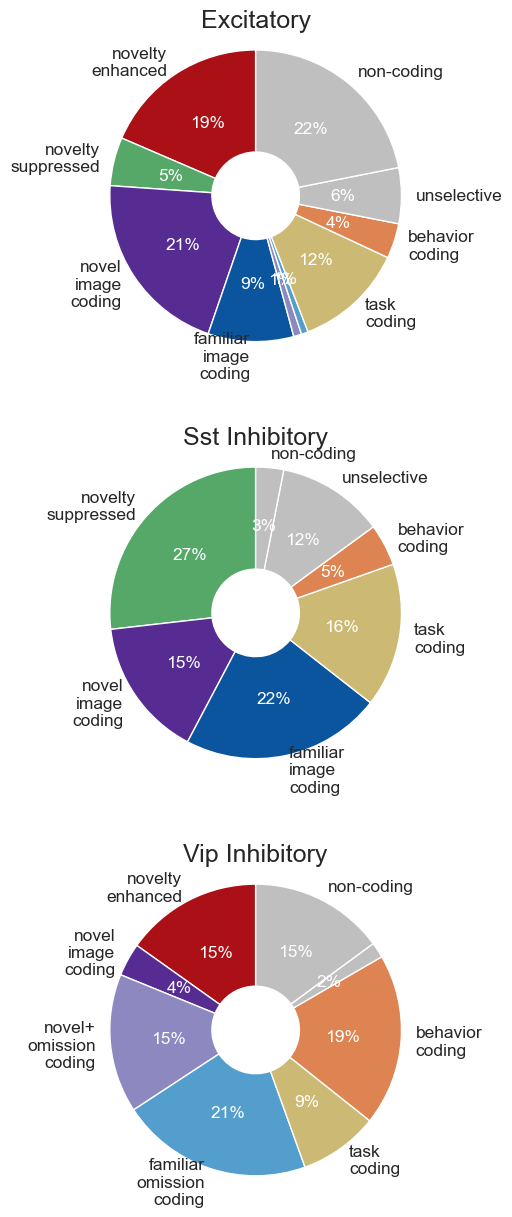

In [70]:
figsize = (5, 15)
fig, ax = plt.subplots(3, 1, figsize=figsize)

for i, cell_type in enumerate(cell_types): 
    # get data for this cell type, with cluster labels & colors in a specific order
    data = counts[counts.cell_type==cell_type]
    fractions = []
    colors = []
    cluster_labels = []
    for c, cluster_label in enumerate(hue_order): 
        tmp = data[data.cluster_label==cluster_label]
        if len(tmp)>0: 
            fractions.append(tmp.fraction.values[0])
            colors.append(palette[c])
            if tmp.fraction.values[0]<=0.03: 
                label = ''
            else: 
                label = cluster_label.replace(' ','\n')
            cluster_labels.append(label)

    # plot it 
    wedges, texts, autotexts = ax[i].pie(fractions, 
                                        labels=cluster_labels, 
                                        autopct='%.0f%%',
                                        startangle=90, 
                                        wedgeprops={'width': 0.7, 'edgecolor': 'white'},   
                                        textprops={'size': 'x-small'},
                                        colors=colors) # Use a Seaborn color palette
    ax[i].axis('equal') 
    ax[i].set_title(cell_type)
    for autotext in autotexts:
        autotext.set_color('white')

    # Equal aspect ratio ensures that pie is drawn as a circle.
plt.subplots_adjust(hspace=0.3)

## Composite figure (Figure 5 main)
Gutter-aware panel placement via `panel_grid`. Run the data-loading and per-panel plotting cells above first, then the import cell, then the composite cell.

In [71]:
from visual_behavior.visualization.panel_grid import (
    fig_setup, panel, show_label_gutters, show_decoration_zones,
    check_label_overlap, auto_fit_left, snug_left_to_gutter, snug_top_to_gutter,
)


loading dataset for Familiar 956941846 ...


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

loading dataset for Novel 957759566 ...


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

loading dataset for Novel + 960410028 ...


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

loading umap results from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_clustering_results/umap_results_df.h5
Familiar
Novel
Novel +
Familiar
Novel
Novel +


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2607: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax[i] = sns.barplot(data=cre_data, y='cluster_id', x='percent_cells', order=order, orient='h',
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2607: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax[i] = sns.barplot(data=cre_data, y='cluster_id', x='percent_cells', order=order, orient='h',
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/dimensionality_reduction/clustering/plotting.py:2607: FutureWarning: 

Passing `palette` without assigning `hue` is dep

OVERLAP: axes of panel "A" intrudes into panel "A" (left gutter)


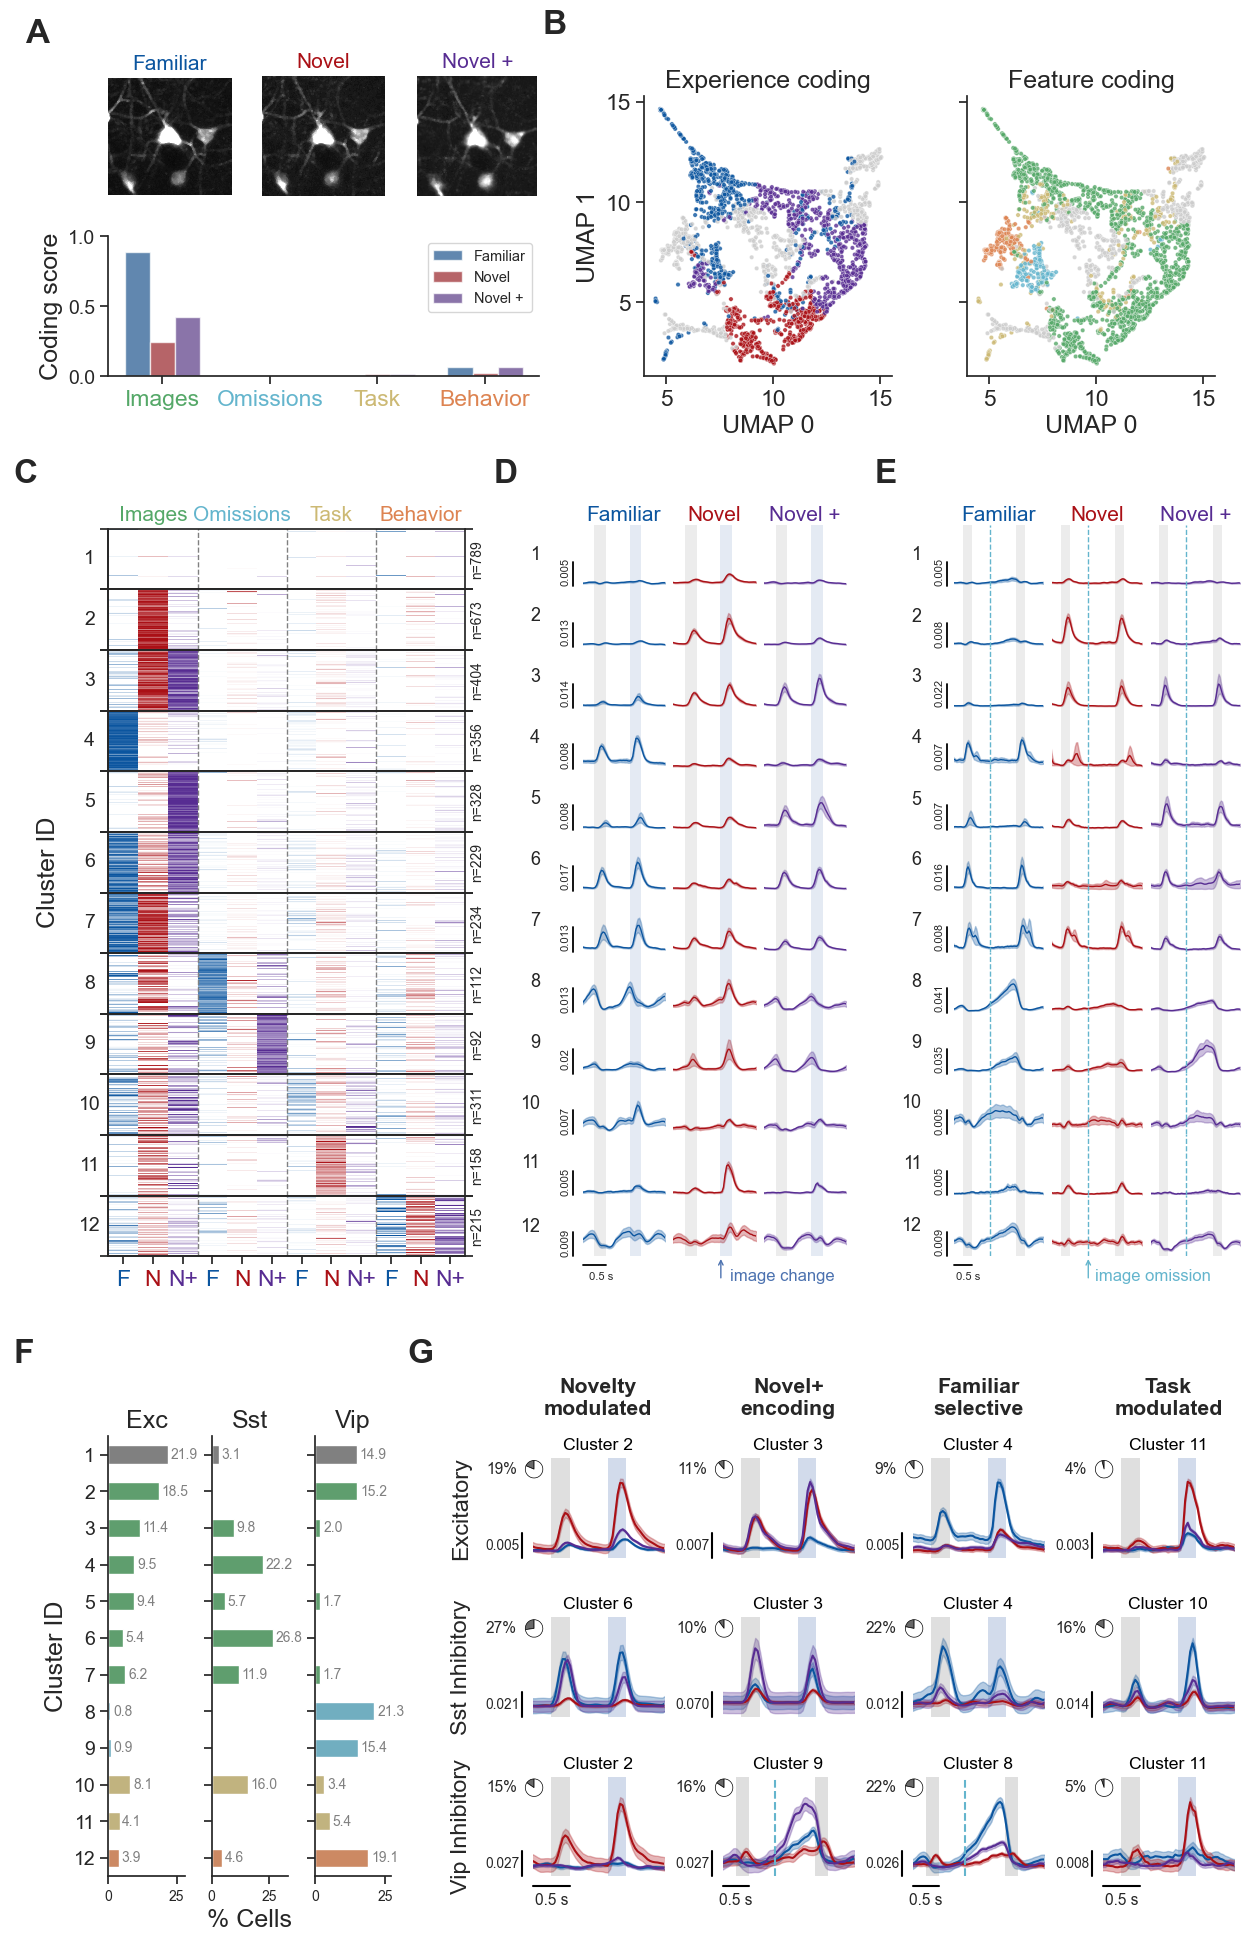

In [72]:
# Composite Figure 5 main - functional clustering of neural responses
#   A  single-cell coding example (3 ROI masks F/N/N+  +  coding-score barplot)
#   B  UMAP (Experience coding | Feature coding)
#   C  cluster coding-score heatmap (one row per cluster)
#   D  per-cluster population CHANGE responses   (clusters x F/N/N+)
#   E  per-cluster population OMISSION responses (clusters x F/N/N+)
#   F  % cells per cluster per cell type (Exc/Sst/Vip), colored by dominant feature
#   G  example clusters per cell type with proportion pies
#
# figsize + REGIONS were derived from 'VBO figures - revised v4.pptx' slide 10 and
# tuned against a data-free mock until check_label_overlap() was clean. The panel
# functions are embedded LIVE (no saved PNGs): C/D/E/F take an axes list, G takes
# fig+bbox, A is assembled from sf.plot_cell_zoom + pse.plot_coding_scores_for_cell.
#
# UPSTREAM (run the data-loading cells above first so these stable vars exist):
#   cluster_meta, feature_matrix, clustering_dir, image_mdf, change_mdf,
#   omission_mdf, results_pivoted, platform_cells_table, platform_experiments.
# Panels B and F are self-contained (they recompute their inputs) so they do NOT
# depend on the exploratory `umap_df`/`colors`/`tmp` that later cells overwrite.
import os
import numpy as np
import visual_behavior.visualization.ophys.summary_figures as sf

figsize = (12.3, 20.0)
fig = plt.figure(figsize=figsize)
fig_setup(fig)

# REGIONS [x0, x1, y0, y1] in figure fraction, y TOP-DOWN.
# Derived from measured slide-10 geometry (letter-anchor -> content, normalized into
# the panels' bounding box), then gaps tuned against a data-free mock until
# check_label_overlap was clean. Layout: A,B top | C,D,E middle |
# F bottom-left (tall, % cells) | G bottom-right (3x4 example clusters).
REGIONS = {
    'A': [0.011, 0.436, 0.000, 0.182],   # top-left  : single-cell coding example
    'B': [0.436, 0.980, 0.000, 0.180],   # top-right : UMAP (flush to figure top)
    'C': [0.001, 0.370, 0.224, 0.624],   # mid-left  : cluster coding heatmap (thinner)
    'D': [0.390, 0.680, 0.224, 0.620],   # mid       : change traces (wider)
    'E': [0.700, 1.000, 0.224, 0.624],   # mid-right : omission traces (wider)
    'F': [0.000, 0.310, 0.665, 0.930],   # BOTTOM-LEFT (tall): % cells per cell type (gap before G)
    'G': [0.320, 0.995, 0.665, 0.930],   # BOTTOM-RIGHT (wide): example clusters 3x4
}
F_GUTTER = (20, 28)   # smaller letter gutter for F so the plot can sit further left

# Per-panel LEFT decoration setback (pt). Smaller than the 80pt default pulls each
# panel's y-label up against its letter gutter (no empty gap). Tuned in the mock so
# no label clips into the gutter -- if a panel ends up with too much/little left
# margin on the real render, nudge its value here. A's ROI row needs almost none;
# A's coding-score bar legitimately needs ~80 (2-line "Coding score" + ticks).
# setbacks bumped vs the mock because the real render's labels are wider than the mock's.
DP = {'A': (16, 0), 'B': (64, 0), 'C': (58, 0), 'D': (58, 0), 'E': (58, 0), 'F': (44, 0)}
DP_A_BAR = (80, 0)

cluster_order = np.sort(cluster_meta.cluster_id.unique())
n_cl = len(cluster_order)

# ---- A: 3 ROI masks (top sub-row) + 1 full-width coding-score bar (bottom) ----
A_CELL = 1086620671
Ax0, Ax1, Ay0, Ay1 = REGIONS['A']
A_top = [Ax0, Ax1, Ay0 + 0.05 * (Ay1 - Ay0), Ay0 + 0.52 * (Ay1 - Ay0)]   # ROI row: taller (lower bottom, same top)
A_bot = [Ax0, Ax1, Ay0 + 0.56 * (Ay1 - Ay0), Ay1]                        # coding-score bar
# A/C/F left-spines are aligned to F's spine: gutter+decoration chosen so each panel's
# inner-axes left edge lands in the same 0.01 cell that F does (verified spine x0 == 0.08).
axA_roi = np.atleast_1d(panel(fig, A_top[:2], A_top[2:], 'A', dim=(1, 3), wspace=0.25,
                              gutter_pt=(20, 28), decoration_pt=(35, 0)))
axA_bar = panel(fig, A_bot[:2], A_bot[2:], None, dim=(1, 1),
                gutter_pt=(0, 0), decoration_pt=(54, 0))

cell_meta_A = platform_cells_table[platform_cells_table.cell_specimen_id == A_CELL]
cell_drop_A = results_pivoted[results_pivoted.cell_specimen_id == A_CELL][
    processing.get_features_for_clustering() + ['experience_level']]
container_A = cell_meta_A.ophys_container_id.unique()[0]
exp_levels_A = ['Familiar', 'Novel', 'Novel +']
exp_colors_A = utils.get_experience_level_colors()
_dsets = globals().get('_fig5_A_datasets', {})   # cache so re-runs don't reload
for e, lvl in enumerate(exp_levels_A):
    oeid = platform_experiments[(platform_experiments.ophys_container_id == container_A) &
                                (platform_experiments.experience_level == lvl)].index.values[0]
    if oeid not in _dsets:
        print('loading dataset for', lvl, oeid, '...')
        _dsets[oeid] = loading.get_ophys_dataset(oeid, get_extended_stimulus_presentations=False)
    ds = _dsets[oeid]
    a = axA_roi[e]
    try:
        roi_id = ds.cell_specimen_table.loc[A_CELL].cell_roi_id
        sf.plot_cell_zoom(ds.roi_masks, ds.max_projection, roi_id,
                          spacex=50, spacey=50, show_mask=False, ax=a)
    except Exception:
        a.axis('off')
    a.set_title(lvl, color=exp_colors_A[e], fontsize=15)
globals()['_fig5_A_datasets'] = _dsets
pse.plot_coding_scores_for_cell(cell_drop_A, ax=axA_bar)
axA_bar.tick_params(axis='y', labelsize=14)                      # match panel C cluster-label size
_acols = [t.get_color() for t in axA_bar.get_xticklabels()]      # capitalize x labels, keep colors
axA_bar.set_xticklabels([t.get_text().capitalize() for t in axA_bar.get_xticklabels()])
for _t, _c in zip(axA_bar.get_xticklabels(), _acols):
    _t.set_color(_c)

# ---- B: UMAP - Experience coding + Feature coding ----
# Self-contained: recompute the UMAP subset + per-cell colors here so panel B does
# NOT depend on the notebook-state `colors`/`edge_colors`/`umap_df`, which later
# cells overwrite (colors -> an 8-element palette, umap_df -> the full table).
_umapB = processing.get_umap_results(feature_matrix, cluster_meta, save_dir=clustering_dir, suffix='')
_umapB['cell_specimen_id'] = cluster_meta.index.values
_umapB = _umapB.set_index('cell_specimen_id')
_mainB = cluster_meta[cluster_meta.cluster_id != 1]          # drop the cluster-1 outlier
_umapB = _umapB.loc[_mainB.index.values]
_keep = _umapB[_umapB.x < 16].index.values                  # drop far outliers
_mainB = _mainB.loc[_keep]; _umapB = _umapB.loc[_keep]

_exp = utils.get_experience_level_colors(); _gray = (0.8, 0.8, 0.8)
_expdict  = {1: _gray, 2: _exp[1], 3: _exp[2], 4: _exp[0], 5: _gray, 6: _exp[2],
             7: _gray, 8: _exp[0], 9: _exp[2], 10: _exp[0], 11: _gray, 12: _gray}
_feat = plotting.get_feature_colors_with_gray()
_featdict = {1: _gray, 2: _feat[1], 3: _feat[1], 4: _feat[1], 5: _gray, 6: _feat[1],
             7: _gray, 8: _feat[2], 9: _feat[2], 10: _feat[3], 11: _gray, 12: _feat[4]}
_cid = _mainB.loc[_umapB.index.values, 'cluster_id'].values
_colB = [_expdict[c] for c in _cid]
_edgeB = [_featdict[c] for c in _cid]

axB = np.atleast_1d(panel(fig, REGIONS['B'][:2], REGIONS['B'][2:], 'B', has_title=True,
                          dim=(1, 2), wspace=0.3, sharey=True, title_room_pt=16,
                          gutter_pt=(20, 28), decoration_pt=(46, 0)))  # tighter letter->plot gap
sns.scatterplot(data=_umapB, x='x', y='y', s=10, ax=axB[0], color=_colB, alpha=0.8)
axB[0].set_title('Experience coding'); axB[0].set_xlabel('UMAP 0'); axB[0].set_ylabel('UMAP 1')
sns.scatterplot(data=_umapB, x='x', y='y', s=10, ax=axB[1], color=_edgeB, alpha=0.8)
axB[1].set_title('Feature coding'); axB[1].set_xlabel('UMAP 0')
axB[1].set_ylabel(''); axB[1].tick_params(labelleft=False)   # shared y; drop the stray 'y' label
for _a in axB:                                               # matching ticks in increments of 5
    _a.set_xticks([5, 10, 15]); _a.set_yticks([5, 10, 15])

# ---- C: cluster coding-score heatmap (one row per cluster) ----
axC = list(np.atleast_1d(panel(fig, REGIONS['C'][:2], REGIONS['C'][2:], 'C',
                               dim=(n_cl, 1), hspace=0.0, has_title=True, title_room_pt=24,
                               gutter_pt=(20, 28), decoration_pt=(45, 0))))  # spine aligned to F; title room for headers
plotting.plot_coding_score_heatmap_matched(
    cluster_meta, feature_matrix, sort_by='cluster_id', cluster_order=cluster_order,
    session_colors=True, experience_index=None, title='',
    save_dir=None, folder=None, suffix='', ax=axC)

# ---- D: population CHANGE responses per cluster ----
axD_grid = np.array(panel(fig, REGIONS['D'][:2], REGIONS['D'][2:], 'D',
                          dim=(n_cl, 3), hspace=0.0, wspace=0.1, sharey='row', sharex=True,
                          has_title=True, title_room_pt=24, gutter_pt=(20, 28), decoration_pt=DP['D']))
axD_flat = [a for row in axD_grid for a in row]
plotting.plot_population_average_response_for_clusters_as_rows_split(
    change_mdf, 'changes', with_pre_change=True, cluster_order=cluster_order,
    ax=axD_flat, save_dir=None, cluster_id_fontsize=13, fill_alpha=0.3,
    cluster_id_xoffset=0.9, arrow_label_fontsize=12)

# ---- E: population OMISSION responses per cluster ----
axE_grid = np.array(panel(fig, REGIONS['E'][:2], REGIONS['E'][2:], 'E',
                          dim=(n_cl, 3), hspace=0.0, wspace=0.1, sharey='row', sharex=True,
                          has_title=True, title_room_pt=24, gutter_pt=(20, 28), decoration_pt=DP['E']))
axE_flat = [a for row in axE_grid for a in row]
plotting.plot_population_average_response_for_clusters_as_rows_split(
    omission_mdf, 'omissions', with_pre_change=True, cluster_order=cluster_order,
    ax=axE_flat, save_dir=None, cluster_id_fontsize=13, fill_alpha=0.3,
    cluster_id_xoffset=0.9, arrow_label_fontsize=12)

# D/E experience-level column labels (Familiar/Novel/Novel+): centered over each
# column (x=0.5), close to the plots (small pad), bigger (15pt)
for _grid in (axD_grid, axE_grid):
    for _a in _grid[0]:
        _t = _a.get_title()
        if _t:
            _a.set_title(_t, color=_a.title.get_color(), fontsize=15, x=0.5, pad=3)

# ---- F: % cells per cluster per cell type (colored by dominant feature) ----
# Self-contained: rebuild cluster_meta + per-cluster dominant_feature from stable
# inputs (cluster_meta, results_pivoted), not the notebook-state `tmp` (overwritten).
_cm_metrics = processing.get_coding_score_metrics_for_clusters(cluster_meta, results_pivoted)
_domF = _cm_metrics['dominant_feature']          # index = cluster_id
tmpF = cluster_meta.copy()
if 'cell_specimen_id' not in tmpF.columns:
    tmpF = tmpF.reset_index()
tmpF['dominant_feature_cluster'] = tmpF['cluster_id'].map(_domF)

axF = list(np.atleast_1d(panel(fig, REGIONS['F'][:2], REGIONS['F'][2:], 'F', has_title=True,
                               dim=(1, 3), wspace=0.35, sharey=True,   # wider gaps so bar value labels show
                               gutter_pt=F_GUTTER, decoration_pt=DP['F'])))
plotting.plot_percent_cells_per_cluster_per_cre_dominant_feature(
    tmpF, col_to_group='cre_line', square=True, cluster_order=cluster_order,
    save_dir=None, ax=axF)
# sharey: only the leftmost column shows cluster-ID tick labels (axes already share y).
# y-tick + "Cluster ID" label keep their full autoscaled size; DP['F'] is sized so that
# (bigger) label sits snug against the letter gutter.
for _a in axF[1:]:
    _a.tick_params(labelleft=False)
for _a in axF:
    _a.tick_params(axis='x', labelsize=10)   # % Cells tick labels
axF[0].tick_params(axis='y', labelsize=14)   # cluster-ID ticks match panel C

# ---- G: example clusters per cell type (with proportion pies) ----
# reserve the letter + gutter with panel(), then embed the multi-axes grid via fig+bbox
axG_lbl = panel(fig, REGIONS['G'][:2], REGIONS['G'][2:], 'G', dim=(1, 1))
axG_lbl.axis('off')
# Insets tuned in the mock so the embedded grid's col-0 cell-type labels (drawn at
# ax.transAxes x=-0.55) and 2-line column headers clear the G letter gutter.
G_INSET_L, G_INSET_T = 0.105, 0.056   # left: grid near the G letter (20pt gutter); top: headers clear it
G_FONT = 1.4   # scale up all of panel G's fonts
G_bbox = [REGIONS['G'][0] + G_INSET_L, REGIONS['G'][2] + G_INSET_T,
          REGIONS['G'][1], REGIONS['G'][3]]
_, axG = plotting.plot_mean_cluster_response_profiles(
    image_mdf, change_mdf, omission_mdf, fig=fig, bbox=G_bbox, fontsize_scale=G_FONT,
    linewidth=1.5, fill_alpha=0.3)
# bump the per-axes fonts the function sets internally (titles, tick labels, the
# rotated cell-type row labels, and the pie % text live on the axes themselves)
for _a in np.array(axG, dtype=object).ravel():
    if _a.get_title():
        _a.title.set_fontsize(_a.title.get_fontsize() * G_FONT)
    _a.tick_params(labelsize=8 * G_FONT)
    for _t in _a.texts:
        _t.set_fontsize(_t.get_fontsize() * G_FONT)

# ---- snap inner-panel y-labels right up against their gutters (MEASURED, not guessed) ----
# B/D/E aren't leftmost, so their labels can't spill into the margin like A/C/F -- this
# rescales each about its right edge so the leftmost label lands at gutter+2pt. Pass each
# panel's own gutter (B uses 20pt, D/E use 32pt). G can't snap (its row labels would hit
# the letter); A/C/F are left aligned already, so leave them.
snug_left_to_gutter(fig, REGIONS, only=['B'], gutter_pt=(20, 28))
snug_left_to_gutter(fig, REGIONS, only=['D', 'E'], gutter_pt=(20, 28))
# pull the has_title panels' column headers up to the top gutter (removes excess title_room)
snug_top_to_gutter(fig, REGIONS, only=['C', 'D', 'E'])

# ---- audit + save ----
# NOTE: A, C, F will each report a "left gutter" intrusion -- this is EXPECTED and intended:
# their spines are aligned to F (far left), so the rotated y-labels sit in the gutter strip,
# beside (not overlapping) the panel letters, which are at the top. Any OTHER warning is real.
check_label_overlap(fig, REGIONS, gutter_pt=F_GUTTER)
utils.save_figure(fig, figsize, save_dir, 'composite', 'figure_5_main_composite')


## Find the 5 best example cells per cell type and plot coding scores + image-response inset
For each cell type, ranks cells by their max |coding score| (across features and experience levels),
keeping only cells with a max mean image response > 0.002 and matched across all 3 experience levels
(needed for the inset), then plots `plot_coding_scores_for_cell_with_response_inset` for the top 5.
Requires upstream vars: `results_pivoted`, `image_mdf`, `cluster_meta`, `platform_cells_table`, `platform_experiments`.
NOTE: this loads ophys datasets for every plotted cell, so the first run can be slow.

In [73]:
# --- rank cells: high |coding score| (any feature/experience level) + image response > 0.002 ---
features = processing.get_features_for_clustering()

cs = results_pivoted.copy()
cs['max_coding_score'] = cs[features].abs().max(axis=1)
cell_cs = cs.groupby('cell_specimen_id')['max_coding_score'].max()

cell_resp = image_mdf.groupby('cell_specimen_id')['mean_response'].max()

# cells matched across all 3 experience levels (needed for the F/N/N+ inset)
matched3 = image_mdf.groupby('cell_specimen_id')['experience_level'].nunique()
matched3 = matched3[matched3 == 3].index

summary = pd.concat([cell_cs, cell_resp.rename('max_image_response')], axis=1).dropna()
summary = summary[(summary.max_image_response > 0.002) & (summary.index.isin(matched3))]
summary['cell_type'] = cluster_meta.loc[summary.index, 'cell_type']

# top 5 cells per cell type, ranked by coding score
best = summary.sort_values('max_coding_score', ascending=False).groupby('cell_type').head(5)
print(best)


                  max_coding_score  max_image_response       cell_type
cell_specimen_id                                                      
1086490095                1.000000            0.004369      Excitatory
1086573206                1.000000            0.043278  Sst Inhibitory
1086573397                1.000000            0.003024      Excitatory
1086513171                1.000000            0.007960      Excitatory
1086512693                1.000000            0.002006      Excitatory
1086574338                1.000000            0.004236      Excitatory
1086575038                1.000000            0.017868  Vip Inhibitory
1086573210                1.000000            0.011329  Vip Inhibitory
1086580607                1.000000            0.030882  Sst Inhibitory
1086613911                1.000000            0.011285  Vip Inhibitory
1086615099                1.000000            0.035365  Vip Inhibitory
1086615307                1.000000            0.002641  Vip Inhibitory
108655

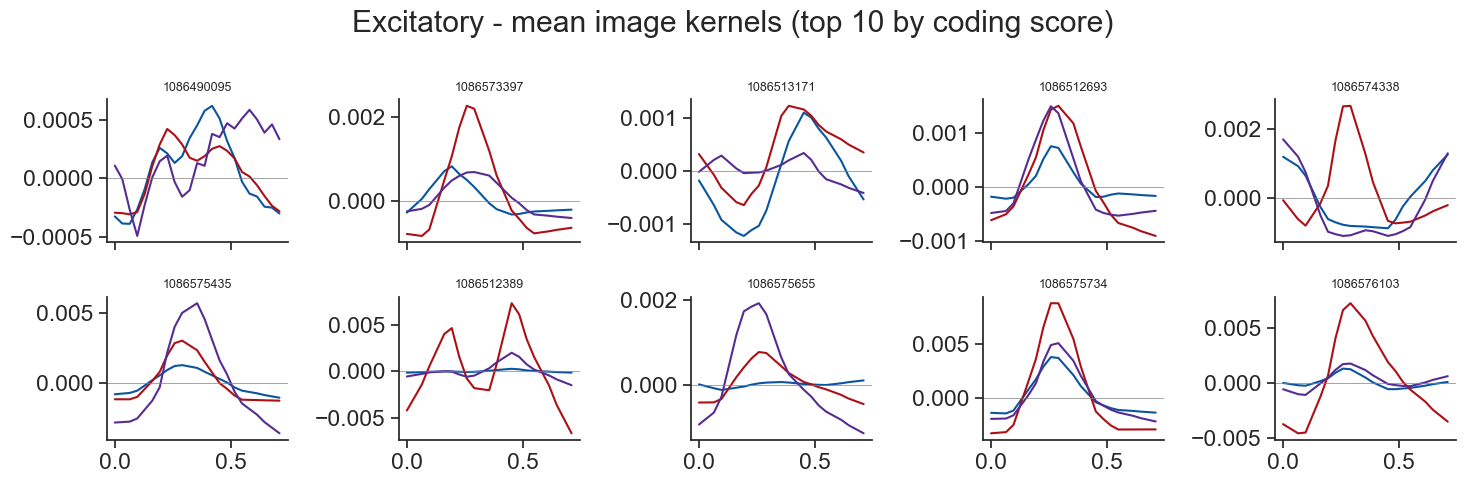

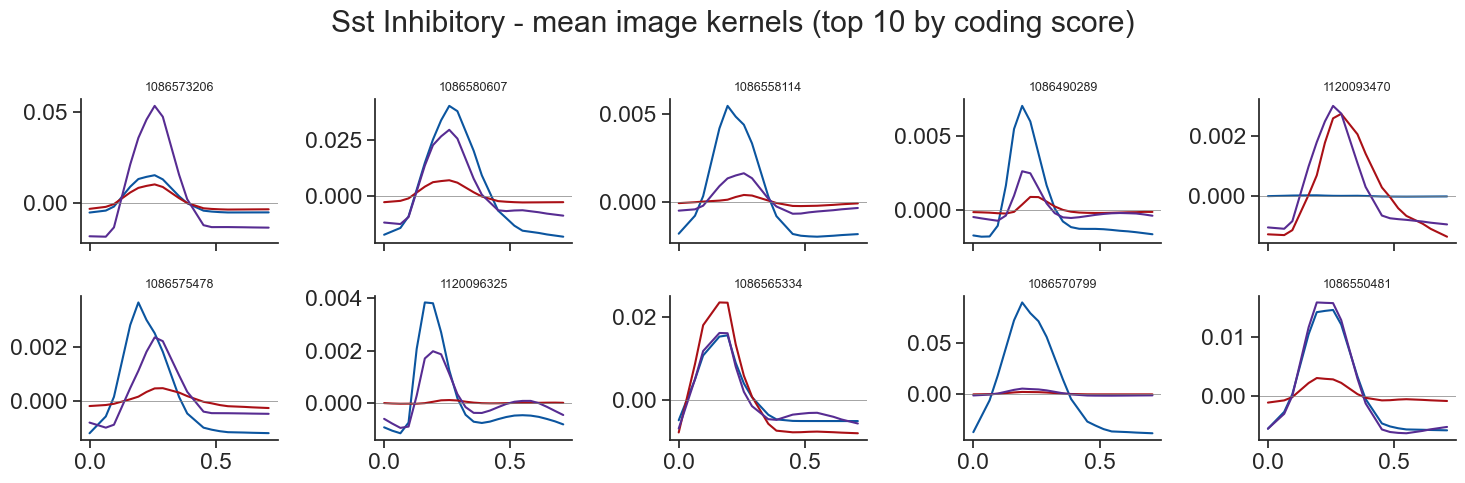

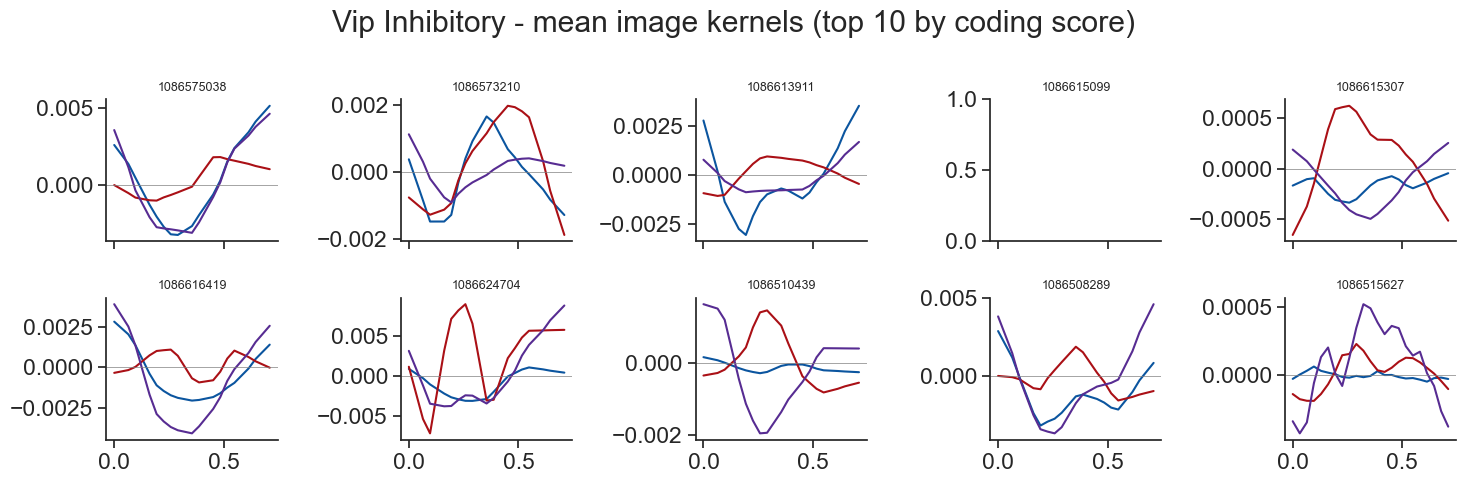

In [74]:
### plot weights for top 10 cells from each cell type
# Inspect candidate cells cheaply (no NWB download) by plotting their mean image kernels from weights_df.
# Pick the good-looking ones, then plot the coding-score + response inset only for those in the cell below.

# load GLM weights + kernels once (commented out in the setup cells above)
if 'weights_df' not in globals():
    glm_version = '24_events_all_L2_optimize_by_session'
    run_params = pd.read_pickle(os.path.join(loading.get_glm_results_dir(), glm_version + '_run_params.pkl'))
    kernels = run_params['kernels']
    weights_df = pd.read_hdf(os.path.join(loading.get_glm_results_dir(),
                                          'platform_results_weights_df.h5'), key='df')

# identify candidates (cheap): high |coding score| (any feature/exp level) + image response > 0.002,
# matched across all 3 experience levels
features = processing.get_features_for_clustering()
cs = results_pivoted.copy()
cs['max_coding_score'] = cs[features].abs().max(axis=1)
cell_cs = cs.groupby('cell_specimen_id')['max_coding_score'].max()
cell_resp = image_mdf.groupby('cell_specimen_id')['mean_response'].max()
matched3 = image_mdf.groupby('cell_specimen_id')['experience_level'].nunique()
matched3 = matched3[matched3 == 3].index
summary = pd.concat([cell_cs, cell_resp.rename('max_image_response')], axis=1).dropna()
summary = summary[(summary.max_image_response > 0.002) & (summary.index.isin(matched3))]
summary['cell_type'] = cluster_meta.loc[summary.index, 'cell_type']
candidates = summary.sort_values('max_coding_score', ascending=False).groupby('cell_type').head(10)

# image kernel columns in weights_df (image0_weights .. image7_weights)
image_features = [c[:-len('_weights')] for c in weights_df.columns
                  if c.startswith('image') and c.endswith('_weights')]
# NOTE: weights_df labels experience levels as 'Familiar'/'Novel 1'/'Novel >1' (NOT utils' 'Novel'/'Novel +');
# index-align these to the experience-level colors
weights_exp_levels = ['Familiar', 'Novel 1', 'Novel >1']
experience_level_colors = utils.get_experience_level_colors()
frame_rate = 31
t_array = pse.get_t_array_for_kernel(kernels, image_features[0], frame_rate)

# one figure per cell type; each subplot = one cell's mean image kernel across experience levels
for cell_type in candidates.cell_type.unique():
    cids = candidates[candidates.cell_type == cell_type].index.values
    fig, axes = plt.subplots(2, 5, figsize=(15, 5), sharex=True)
    axes = axes.ravel()
    for j, cell_specimen_id in enumerate(cids):
        ax = axes[j]
        cell_weights = weights_df[weights_df.cell_specimen_id == cell_specimen_id]
        for exp_level, color in zip(weights_exp_levels, experience_level_colors):
            exp_weights = cell_weights[cell_weights.experience_level == exp_level]
            if len(exp_weights) == 0:
                continue
            image_weights = [np.asarray(exp_weights[f + '_weights'].values[0]) for f in image_features]
            # skip experience levels with un-fit kernels (stored as a scalar/length-1 instead of full kernel)
            if any(iw.shape != (len(t_array),) for iw in image_weights):
                continue
            mean_image_weights = np.mean(image_weights, axis=0)
            ax.plot(t_array, mean_image_weights, color=color)
        ax.axhline(0, color='gray', lw=0.5)
        ax.set_title(str(cell_specimen_id), fontsize=9)
    for j in range(len(cids), len(axes)):
        axes[j].axis('off')
    fig.suptitle(cell_type + ' - mean image kernels (top ' + str(len(cids)) + ' by coding score)')
    fig.tight_layout()

In [76]:
cell_drop

,all-images,omissions,task,behavioral,ophys_experiment_id,cell_specimen_id,experience_level
identifier,,,,,,,
873970531_1086510439,0.000000,0.0,0.000000,0.00000,873970531,1086510439,Familiar
877057351_1086510439,0.000000,1.0,0.329508,0.00000,877057351,1086510439,Novel +
877669822_1086510439,0.215131,0.0,0.057466,0.38644,877669822,1086510439,Novel


cells to plot: [1086573397, 1086574338, 1086573206, 1086558114, 1086570799, 1086575038, 1086510439]
loading dataset 989213063 ...


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

loading dataset 990400781 ...


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

loading dataset 991852005 ...


...

saved response df to /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_stimulus_response_dfs/873970531_events_images.h5
generating response df


100%|██████████| 13/13 [00:02<00:00,  4.43it/s]
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/loading.py:865: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['trace', 'trace_timestamps', 'data_type', 'event_type'], dtype='object')]

  sdf.to_hdf(filepath, key='df')


saved response df to /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_stimulus_response_dfs/877669822_events_images.h5
generating response df


100%|██████████| 18/18 [00:04<00:00,  4.41it/s]
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/loading.py:865: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['trace', 'trace_timestamps', 'data_type', 'event_type'], dtype='object')]

  sdf.to_hdf(filepath, key='df')


saved response df to /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_stimulus_response_dfs/877057351_events_images.h5


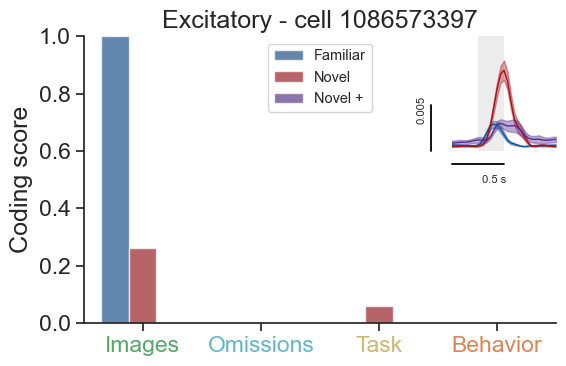

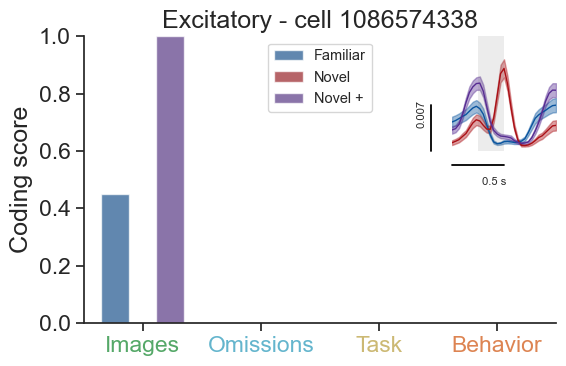

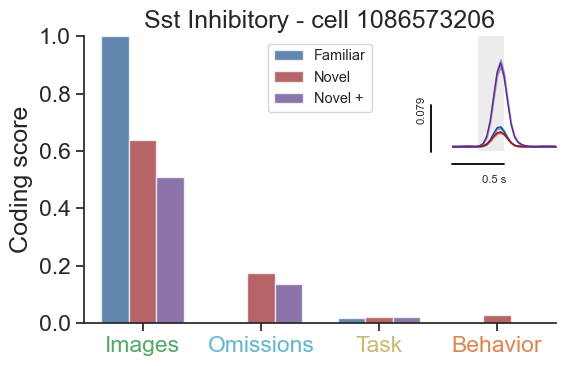

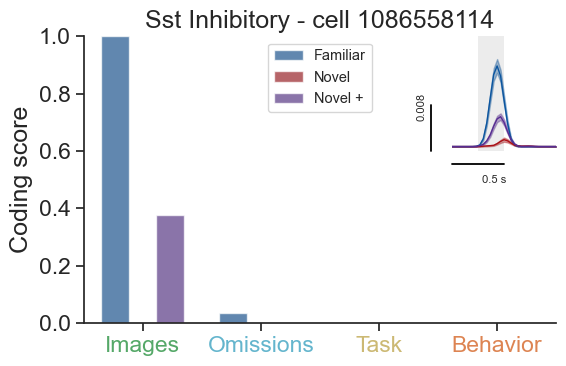

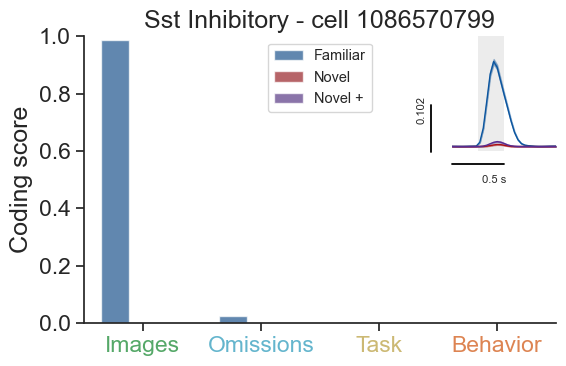

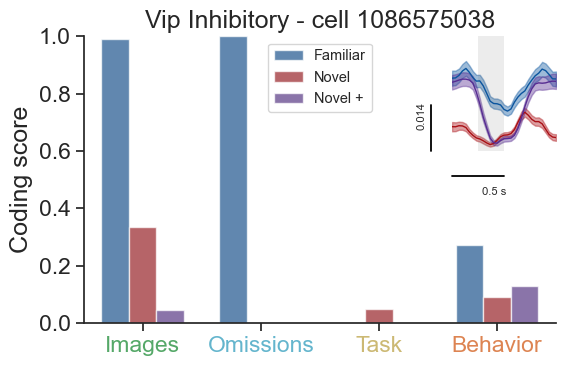

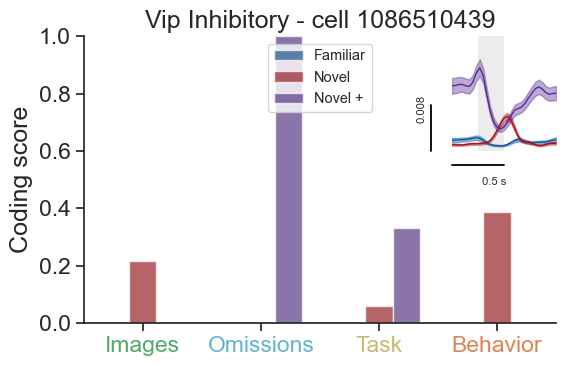

In [75]:
# --- selected example cells (by position in the weights grid, 1-indexed, ranked by coding score) ---
picks = {
    'Excitatory':     [2, 5],
    'Sst Inhibitory': [1, 3, 9],
    'Vip Inhibitory': [1, 8],
}
cells_to_plot = []
for cell_type, positions in picks.items():
    cids = candidates[candidates.cell_type == cell_type].index.values
    cells_to_plot += [int(cids[p - 1]) for p in positions]
print('cells to plot:', cells_to_plot)

# --- plot coding scores + image-response inset for each selected cell ---
SKIP_OEID = 842973730   # this experiment is very slow to load, skip any cell that includes it
datasets_cache = globals().get('_fig5_A_datasets', {})   # reuse the panel-A dataset cache
for cell_specimen_id in cells_to_plot:
    cell_type = cluster_meta.loc[cell_specimen_id, 'cell_type']
    cell_drop = results_pivoted[results_pivoted.cell_specimen_id == cell_specimen_id]   # keep ALL columns
    container = platform_cells_table[platform_cells_table.cell_specimen_id ==
                                      cell_specimen_id].ophys_container_id.unique()[0]
    oeids = platform_experiments[platform_experiments.ophys_container_id == container].index.values
    if SKIP_OEID in oeids:
        print('skipping cell', cell_specimen_id, '- associated with experiment', SKIP_OEID)
        continue
    for oeid in oeids:
        if oeid not in datasets_cache:
            print('loading dataset', oeid, '...')
            datasets_cache[oeid] = loading.get_ophys_dataset(oeid, get_extended_stimulus_presentations=False)

    fig, ax = plt.subplots(figsize=(6, 4))
    pse.plot_coding_scores_for_cell_with_response_inset(cell_drop, datasets_cache, data_type='events',
                                                        legend=True, ax=ax)
    ax.set_title(cell_type + ' - cell ' + str(cell_specimen_id))
    fig.tight_layout()
globals()['_fig5_A_datasets'] = datasets_cache

## Panel A variant: coding-score barplot with image-response inset
Demonstrates `pse.plot_coding_scores_for_cell_with_response_inset`, which draws the same
coding-score barplot as panel A but adds an inset (formatted like the cluster population-average
plots: no spines, with time + response scale bars) showing this cell's average change-triggered
response to images, overlaid across experience levels (colored by experience level).

Datasets are loaded **once** into a dict (`datasets_A`, keyed by `ophys_experiment_id`) and passed
into the function, so re-running this cell to tweak the plot does not reload them. Also note this
version needs the un-stripped per-cell rows (keep `ophys_experiment_id` / `cell_specimen_id`).
Requires the panel-A upstream vars (`A_CELL`, `results_pivoted`, `platform_cells_table`,
`platform_experiments`) from the composite cell above.

In [ ]:
# other example cell options 
cell_specimen_id = 1086514606 #Excitatory behavior coding cell
cell_specimen_id = 1086620671  
cell_specimen_id = 1086628708  


In [ ]:
# other example cell options 
cell_specimen_id = 1086514606 #Excitatory behavior coding cell
cell_specimen_id = 1086620671  
cell_specimen_id = 1086628708  

# load the datasets ONCE (keyed by ophys_experiment_id) so replots don't reload them.
# reuses the composite panel-A cache (_fig5_A_datasets) if it already exists.
cell_drop_A_full = results_pivoted[results_pivoted.cell_specimen_id == A_CELL]   # keep ALL columns
container_A = platform_cells_table[platform_cells_table.cell_specimen_id == A_CELL].ophys_container_id.unique()[0]
datasets_A = globals().get('_fig5_A_datasets', {})
for oeid in platform_experiments[platform_experiments.ophys_container_id == container_A].index.values:
    if oeid not in datasets_A:
        print('loading dataset', oeid, '...')
        datasets_A[oeid] = loading.get_ophys_dataset(oeid, get_extended_stimulus_presentations=False)
globals()['_fig5_A_datasets'] = datasets_A


In [ ]:
# load the datasets ONCE (keyed by ophys_experiment_id) so replots don't reload them.
# reuses the composite panel-A cache (_fig5_A_datasets) if it already exists.
cell_drop_A_full = results_pivoted[results_pivoted.cell_specimen_id == A_CELL]   # keep ALL columns
container_A = platform_cells_table[platform_cells_table.cell_specimen_id == A_CELL].ophys_container_id.unique()[0]
datasets_A = globals().get('_fig5_A_datasets', {})
for oeid in platform_experiments[platform_experiments.ophys_container_id == container_A].index.values:
    if oeid not in datasets_A:
        print('loading dataset', oeid, '...')
        datasets_A[oeid] = loading.get_ophys_dataset(oeid, get_extended_stimulus_presentations=False)
globals()['_fig5_A_datasets'] = datasets_A


In [ ]:

fig, ax = plt.subplots(figsize=(6, 4))
pse.plot_coding_scores_for_cell_with_response_inset(cell_drop_A_full, datasets_A, data_type='events', legend=True, ax=ax)
ax.set_title('')
fig.tight_layout()

In [78]:
# other example cell options 
# cell_specimen_id = 1086514606 #Excitatory behavior coding cell
# cell_specimen_id = 1086620671  
# cell_specimen_id = 1086628708  
cell_specimen_id = 1086558114 # Sst, familiar encoding

# load the datasets ONCE (keyed by ophys_experiment_id) so replots don't reload them.
# reuses the composite panel-A cache (_fig5_A_datasets) if it already exists.
cell_drop_A_full = results_pivoted[results_pivoted.cell_specimen_id == cell_specimen_id]   # keep ALL columns
container_A = platform_cells_table[platform_cells_table.cell_specimen_id == cell_specimen_id].ophys_container_id.unique()[0]
# datasets_A = globals().get('_fig5_A_datasets', {})
datasets_A = {}
for oeid in platform_experiments[platform_experiments.ophys_container_id == container_A].index.values:
    if oeid not in datasets_A:
        print('loading dataset', oeid, '...')
        datasets_A[oeid] = loading.get_ophys_dataset(oeid, get_extended_stimulus_presentations=False)
# globals()['_fig5_A_datasets'] = datasets_A


loading dataset 850517346 ...


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

loading dataset 853363743 ...


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

loading dataset 854759894 ...


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_single_cell_examples.py:1827: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.capitalize() for label in feature_labels])


file exists:
loading response df from file for 850517346 events images
sdf loaded
file exists:
loading response df from file for 853363743 events images
sdf loaded
file exists:
loading response df from file for 854759894 events images
sdf loaded


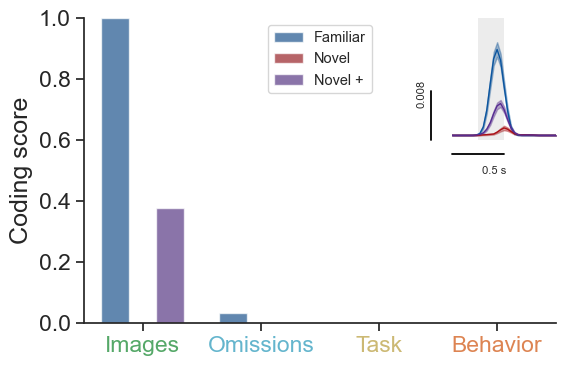

In [79]:
fig, ax = plt.subplots(figsize=(6, 4))
pse.plot_coding_scores_for_cell_with_response_inset(cell_drop_A_full, datasets_A, data_type='events', legend=True, ax=ax)
ax.set_title('')
fig.tight_layout()

In [80]:
datasets_A

{850517346: <allensdk.brain_observatory.behavior.behavior_ophys_experiment.BehaviorOphysExperiment at 0xb6db7dbb0>,
 853363743: <allensdk.brain_observatory.behavior.behavior_ophys_experiment.BehaviorOphysExperiment at 0x9596ffb80>,
 854759894: <allensdk.brain_observatory.behavior.behavior_ophys_experiment.BehaviorOphysExperiment at 0x33feabfd0>}

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

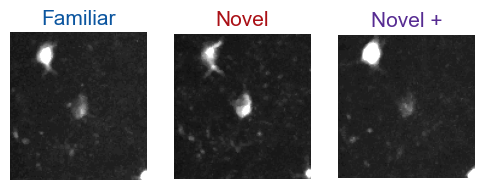

In [87]:
cell_meta_A = platform_cells_table[platform_cells_table.cell_specimen_id == cell_specimen_id]
cell_drop_A = results_pivoted[results_pivoted.cell_specimen_id == cell_specimen_id][
    processing.get_features_for_clustering() + ['experience_level']]
# container_A = cell_meta_A.ophys_container_id.unique()[0]
exp_levels_A = ['Familiar', 'Novel', 'Novel +']
exp_colors_A = utils.get_experience_level_colors()
fig, ax = plt.subplots(1, 3, figsize=(6, 4))
for e, lvl in enumerate(exp_levels_A):
    oeid = platform_experiments[(platform_experiments.ophys_container_id == container_A) &
                                (platform_experiments.experience_level == lvl)].index.values[0]
    datasets_A[oeid] = loading.get_ophys_dataset(oeid, get_extended_stimulus_presentations=False)
    ds = datasets_A[oeid]
    a = ax[e]
    # try:
    roi_id = ds.cell_specimen_table.loc[cell_specimen_id].cell_roi_id
    sf.plot_cell_zoom(ds.roi_masks, ds.max_projection, roi_id,
                        spacex=50, spacey=50, show_mask=False, ax=a)
    # except Exception:
    #     a.axis('off')
    a.set_title(lvl, color=exp_colors_A[e], fontsize=15)

## Diagnostic: un-normalized dropouts + variance_explained_full for one cell
Loads the within-session (un-normalized) dropouts from `platform_results_pivoted.h5` (which include
`variance_explained_full`), prints the scores for the cell, and remakes the coding-score + image-response
inset plot using the un-normalized dropouts. Useful for seeing why a large mean response can coincide with
a low coding score (low VE_full = the response is poorly explained by the model).

experience_level  all-images  omissions      task  behavioral  variance_explained_full
        Familiar   -1.000000   0.000000 -0.017027    0.000000                 0.213047
           Novel   -0.911703  -0.188834 -0.065341   -0.037621                 0.148503
         Novel +   -0.792744  -0.134627 -0.126313    0.000000                 0.136534
file exists:
loading response df from file for 977978331 events images


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_single_cell_examples.py:1827: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.capitalize() for label in feature_labels])


sdf loaded
file exists:
loading response df from file for 978296114 events images
sdf loaded
file exists:
loading response df from file for 981178542 events images
sdf loaded


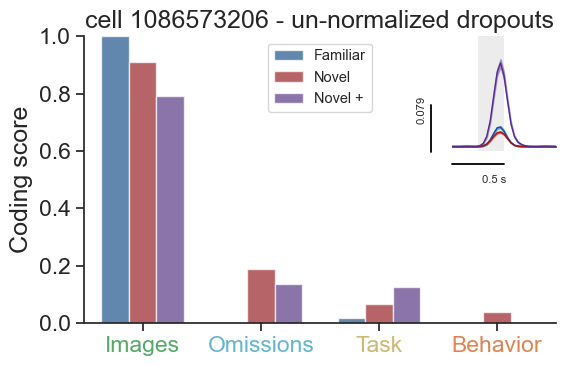

In [77]:
### un-normalized dropouts + VE_full for one cell
CELL = 1086573206

# within-session (un-normalized) dropouts include variance_explained_full
raw_results_pivoted = pd.read_hdf(os.path.join(loading.get_glm_results_dir(),
                                               'platform_results_pivoted.h5'), key='df')
cell_drop_raw = raw_results_pivoted[raw_results_pivoted.cell_specimen_id == CELL]

# print scores (raw dropouts are negative; the plot shows |dropout|)
score_cols = ['experience_level'] + processing.get_features_for_clustering() + ['variance_explained_full']
print(cell_drop_raw[score_cols].to_string(index=False))

# load datasets for this cell's container (reuse the panel-A cache)
container = platform_cells_table[platform_cells_table.cell_specimen_id == CELL].ophys_container_id.unique()[0]
datasets_cache = globals().get('_fig5_A_datasets', {})
for oeid in platform_experiments[platform_experiments.ophys_container_id == container].index.values:
    if oeid not in datasets_cache:
        print('loading dataset', oeid, '...')
        datasets_cache[oeid] = loading.get_ophys_dataset(oeid, get_extended_stimulus_presentations=False)
globals()['_fig5_A_datasets'] = datasets_cache

# coding-score + image-response inset using UN-NORMALIZED dropouts
fig, ax = plt.subplots(figsize=(6, 4))
pse.plot_coding_scores_for_cell_with_response_inset(cell_drop_raw, datasets_cache, data_type='events',
                                                    legend=True, ax=ax)
ax.set_title('cell ' + str(CELL) + ' - un-normalized dropouts')
fig.tight_layout()